# Beautiful Soup — Reading Data Out of Web Pages

A lot of useful data sits on web pages and nowhere else: no API, no CSV download, just a table in
a browser. Web scraping is the practice of fetching those pages and pulling the data out
programmatically, and Beautiful Soup is the library that does the pulling.

This notebook is also where the other three come together. The last project fetches pages, parses
them, loads the results into a DataFrame, computes summaries and draws charts — the whole pipeline.

### What this notebook covers

- Enough HTML to know what you are looking at, and what the DOM is
- The three separate jobs — fetching, parsing, and running JavaScript — and which tool does which
- Parsing with Beautiful Soup: `find`, `find_all`, and CSS selectors with `select`
- Getting text and attributes out of the elements you found
- Navigating the tree when the element you want has no useful class of its own
- `requests`: status codes, headers, timeouts, and not assuming a request succeeded
- Building a complete scraper, then making it a good one
- Pagination
- The ethics and legality, which are not optional reading
- Why Beautiful Soup cannot see JavaScript-rendered content, and what to do about it
- A mini project combining requests, Beautiful Soup, Pandas, NumPy and Matplotlib

### Prerequisites

Basic Python — dictionaries and list comprehensions especially, since scraped records are natural
dictionaries. The Pandas and Matplotlib notebooks are used in the final project. No HTML knowledge
is assumed.

### A note on the examples

Scraping tutorials that point at real websites break, because websites change their markup and
some of them do not want to be scraped. Everything here runs against HTML we generate ourselves
and serve from a small web server started inside this notebook. That means:

- The examples work offline and will still work in a year.
- The HTTP requests are genuine — a real client talking to a real server over a real socket — so
  nothing is being faked or simplified away.
- Nobody's terms of service are involved.

The techniques transfer unchanged to public pages.

## Setup

In [1]:
# %pip install beautifulsoup4 requests pandas matplotlib

In [2]:
import bs4
import requests
from bs4 import BeautifulSoup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("beautifulsoup4:", bs4.__version__)
print("requests      :", requests.__version__)

beautifulsoup4: 4.12.3
requests      : 2.32.3


Note the mismatch between the install name and the import name: you install
**`beautifulsoup4`** and you import **`bs4`**. Installing a package called `BeautifulSoup` gets
you an abandoned version from 2012, which is a genuinely common beginner mistake.

## What HTML actually is

Before parsing HTML it helps to know what you are parsing. HTML describes a document as a set of
nested **elements**.

In [3]:
html_sample = """
<article class="product featured" id="p-1024" data-sku="KB-1024">
  <h2 class="title">Mechanical Keyboard</h2>
  <p class="price">₹4,299</p>
  <p class="rating" data-stars="4">Rated 4 out of 5</p>
  <a href="/products/1024">View details</a>
  <img src="/images/kb-1024.jpg" alt="Mechanical keyboard, black">
</article>
"""

print(html_sample)


<article class="product featured" id="p-1024" data-sku="KB-1024">
  <h2 class="title">Mechanical Keyboard</h2>
  <p class="price">₹4,299</p>
  <p class="rating" data-stars="4">Rated 4 out of 5</p>
  <a href="/products/1024">View details</a>
  <img src="/images/kb-1024.jpg" alt="Mechanical keyboard, black">
</article>



Reading that piece by piece:

```text
<article class="product featured" id="p-1024">
 ↑        └────────────── attributes ───────┘
 tag name

  <h2 class="title">Mechanical Keyboard</h2>
   ↑                └──── text content ──┘  ↑
   opening tag                               closing tag
</article>
```

- A **tag** names the kind of element: `article`, `h2`, `p`, `a`, `img`, `div`, `span`, `table`.
- Most elements have an **opening** and a **closing** tag, and the content sits between them.
  Some — `img`, `br`, `input` — are empty and have no closing tag.
- **Attributes** are `name="value"` pairs inside the opening tag. The ones that matter for scraping:
  - `class` — a styling label, often shared by every element of the same kind. This is usually your
    main handle: every product's price might be `<p class="price">`.
  - `id` — meant to be unique on the page. Useful when you want one specific element.
  - `href` on a link and `src` on an image hold the URL.
  - `data-*` attributes hold values the page author attached for their own scripts. When they
    exist they are often cleaner than the visible text — `data-stars="4"` beats parsing
    "Rated 4 out of 5".
- Elements **nest**. The `h2` is inside the `article`, which might be inside a `div`, which is
  inside `body`. That nesting is the structure you navigate.

### The DOM

Because elements nest, an HTML document is a tree.

```text
html
├── head
│   └── title
└── body
    └── div  (class="catalogue")
        ├── article  (class="product")
        │   ├── h2   (class="title")   →  "Mechanical Keyboard"
        │   ├── p    (class="price")   →  "₹4,299"
        │   └── a    (href=...)        →  "View details"
        └── article  (class="product")
            ├── h2   ...
            └── ...
```

That tree is called the **DOM** — the Document Object Model. Every scraping operation is one of
two things: *search the tree* for elements matching a description, or *walk the tree* from an
element you have already found to a neighbouring one.

Beautiful Soup's whole job is turning the text of an HTML document into this tree and giving you
convenient ways to search and walk it.

### Seeing the real thing

Every browser shows you the DOM. In Chrome, Firefox or Edge: right-click any element on a page and
choose **Inspect**. A panel opens with the tree, the element you clicked highlighted.

Do this before writing any scraper. You are looking for:

1. What tag holds each record (often `<div>`, `<article>`, `<li>`, or `<tr>` in a table).
2. What class or attribute identifies it, and whether every record shares it.
3. Where inside that the fields sit — title, price, link.

Fifteen seconds in the inspector saves twenty minutes of guessing.

## Three different jobs

This is the conceptual point students most often arrive without, and it explains most "why doesn't
my scraper work" questions.

```text
   1. FETCH                2. PARSE                  3. RENDER / EXECUTE
   ───────────             ─────────                 ───────────────────
   requests                Beautiful Soup            Selenium, Playwright
   urllib                  lxml, html.parser         (a real browser)

   Ask a server for        Turn that text into a     Run the page's
   a URL and get           searchable tree and       JavaScript, so content
   back HTML text          pull values out           built by scripts exists
```

- **`requests` fetches.** It performs the HTTP request and hands you back a string. It has no idea
  that string is HTML.
- **Beautiful Soup parses.** Give it HTML text and it builds the tree. It never makes a network
  request — you can hand it HTML from a file, from a database, or typed into a cell, as we did above.
- **A browser automation tool renders.** Selenium and Playwright drive an actual browser, so the
  page's JavaScript runs and the resulting DOM includes anything the scripts built.

The division matters because the two most common failures are each in a different box. "I got a
403" is a fetching problem. "The element I want is not in the HTML at all" is usually a rendering
problem — the data arrives via JavaScript after the initial HTML. Beautiful Soup cannot fix either;
it only ever sees the text you give it.

The last section of this notebook covers how to tell which situation you are in.

## Parsing your first document

In [4]:
soup = BeautifulSoup(html_sample, "html.parser")

print(type(soup))
print(soup.prettify())

<class 'bs4.BeautifulSoup'>
<article class="product featured" data-sku="KB-1024" id="p-1024">
 <h2 class="title">
  Mechanical Keyboard
 </h2>
 <p class="price">
  ₹4,299
 </p>
 <p class="rating" data-stars="4">
  Rated 4 out of 5
 </p>
 <a href="/products/1024">
  View details
 </a>
 <img alt="Mechanical keyboard, black" src="/images/kb-1024.jpg"/>
</article>



```python
soup = BeautifulSoup(html_sample, "html.parser")
                     └─ the HTML ┘  └─ which parser to use ┘
```

The first argument is the HTML **text**. The second names the parser. Always pass it — leaving it
out works but emits a warning, because Beautiful Soup then picks whichever parser is installed and
your code behaves differently on a different machine.

`soup.prettify()` returns the document re-indented to show the nesting. It is the first thing to
reach for when a page's structure is not obvious.

### Which parser

In [5]:
broken_html = "<div class='a'><p>First<p>Second</div>"

for parser in ["html.parser", "lxml"]:
    try:
        parsed = BeautifulSoup(broken_html, parser)
        print(f"{parser:12} → {len(parsed.find_all('p'))} paragraphs found")
    except Exception as e:
        print(f"{parser:12} → not available ({type(e).__name__})")

html.parser  → 2 paragraphs found
lxml         → 2 paragraphs found


That HTML is malformed — the `<p>` tags are never closed. Real pages are full of this, and a
parser's job includes guessing what was meant.

| Parser | Install | Notes |
| --- | --- | --- |
| `"html.parser"` | built in | No install needed. Decent, slower, reasonably forgiving |
| `"lxml"` | `pip install lxml` | Fast, very forgiving. The usual choice for real work |
| `"html5lib"` | `pip install html5lib` | Slowest; parses exactly as a browser would |

Use `"html.parser"` while learning — one less thing to install, and the examples in this notebook
use it. Switch to `"lxml"` when you are scraping a lot of pages or hitting badly broken markup.

On the fragment above both parsers agreed — each recovered two paragraphs. They do not always,
and on badly broken markup they can produce **different trees** from identical input. That is
worth remembering the day a selector works on your machine and not on a colleague's.

## Finding elements

Two families of methods, and you will end up using both.

- `find` / `find_all` — Beautiful Soup's own search, driven by tag names and attributes.
- `select_one` / `select` — CSS selectors, the same syntax stylesheets use.

We need a more realistic page to search. Here is one, written out in full so you can see exactly
what every example is matching against.

In [6]:
catalogue_html = """
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <title>TechBazaar — Peripherals</title>
</head>
<body>
  <header>
    <h1 id="site-title">TechBazaar</h1>
    <nav class="breadcrumb">
      <a href="/">Home</a> &rsaquo;
      <a href="/c/peripherals">Peripherals</a>
    </nav>
  </header>

  <main>
    <h2 class="section-heading">Keyboards &amp; Mice</h2>

    <div class="product-grid">
      <article class="product in-stock" data-sku="KB-1024">
        <h3 class="title"><a href="/products/1024">Mechanical Keyboard TKL</a></h3>
        <p class="brand">Keytron</p>
        <p class="price" data-paise="429900">&#8377;4,299</p>
        <p class="rating" data-stars="4.5">4.5 stars (218 reviews)</p>
        <span class="badge">Bestseller</span>
        <img src="/img/kb-1024.jpg" alt="Mechanical keyboard TKL">
      </article>

      <article class="product in-stock" data-sku="MS-2048">
        <h3 class="title"><a href="/products/2048">Wireless Mouse Pro</a></h3>
        <p class="brand">Glidex</p>
        <p class="price" data-paise="159900">&#8377;1,599</p>
        <p class="rating" data-stars="4.1">4.1 stars (1,043 reviews)</p>
        <img src="/img/ms-2048.jpg" alt="Wireless mouse">
      </article>

      <article class="product out-of-stock" data-sku="KB-3072">
        <h3 class="title"><a href="/products/3072">Ergonomic Split Keyboard</a></h3>
        <p class="brand">Keytron</p>
        <p class="price" data-paise="899900">&#8377;8,999</p>
        <p class="rating" data-stars="4.7">4.7 stars (96 reviews)</p>
        <span class="badge sold-out">Out of stock</span>
        <img src="/img/kb-3072.jpg" alt="Split keyboard">
      </article>
    </div>
  </main>

  <footer>
    <p class="note">Prices include GST.</p>
  </footer>
</body>
</html>
"""

soup = BeautifulSoup(catalogue_html, "html.parser")
print("parsed. page title:", soup.title.text)

parsed. page title: TechBazaar — Peripherals


### `find` — the first match

In [7]:
first_product = soup.find("article")

print(type(first_product))
print(first_product.find("h3").text)

<class 'bs4.element.Tag'>
Mechanical Keyboard TKL


`soup.find("article")` returns the **first** `<article>` in document order, as a `Tag` object.
A `Tag` behaves like a small soup of its own — you can call `find` on it to search only inside it,
which is how you scope a search to one record.

When nothing matches, `find` returns `None`:

In [8]:
missing = soup.find("table")
print("result:", missing)
print("type  :", type(missing))

result: None
type  : <class 'NoneType'>


This is the single most common scraping crash. `None` has no `.text`, so the next line fails:

In [9]:
try:
    print(soup.find("table").text)
except AttributeError as e:
    print("AttributeError:", e)

AttributeError: 'NoneType' object has no attribute 'text'


`'NoneType' object has no attribute 'text'` always means the same thing: **your search found
nothing**. The bug is not on the line that crashed; it is in the search on the line before, or on
a page that does not have the element you expected.

Handling it properly:

In [10]:
table = soup.find("table")
if table is not None:
    print(table.text)
else:
    print("no table on this page — carrying on")

no table on this page — carrying on


### `find_all` — every match

In [11]:
products = soup.find_all("article")

print("found", len(products), "products")
for product in products:
    print(" -", product.find("h3").text)

found 3 products
 - Mechanical Keyboard TKL
 - Wireless Mouse Pro
 - Ergonomic Split Keyboard


`find_all` returns a list-like `ResultSet`. It supports `len()`, indexing and iteration, and when
nothing matches you get an **empty list** rather than `None` — so a `for` loop over it simply does
nothing, which is why missing data in a `find_all` scraper shows up as an empty result rather than
a crash.

In [12]:
print("nothing matched:", soup.find_all("table"))
print("length:", len(soup.find_all("table")))

nothing matched: []
length: 0


### Searching by class

In [13]:
print("by class name:")
for price in soup.find_all(class_="price"):
    print(" ", price.text)

by class name:
  ₹4,299
  ₹1,599
  ₹8,999


Note **`class_`** with a trailing underscore. `class` is a reserved Python keyword, so Beautiful
Soup uses `class_` instead. Getting this wrong gives you a `SyntaxError`, which at least tells you
immediately.

Combining a tag name with a class is the most common search of all:

In [14]:
print(soup.find("p", class_="brand").text)
print(len(soup.find_all("p", class_="price")), "price paragraphs")

Keytron
3 price paragraphs


### The multiple-class subtlety

Our products have `class="product in-stock"` — two classes on one element. Beautiful Soup matches
if **any** of the element's classes matches:

In [15]:
print("class_='product'    →", len(soup.find_all(class_="product")))
print("class_='in-stock'   →", len(soup.find_all(class_="in-stock")))
print("class_='out-of-stock' →", len(soup.find_all(class_="out-of-stock")))
print('class_="product in-stock" →', len(soup.find_all(class_="product in-stock")))

class_='product'    → 3
class_='in-stock'   → 2
class_='out-of-stock' → 1
class_="product in-stock" → 2


The last one returns 2, matching only elements whose class attribute is exactly that string in that
order — so it is fragile. For "has both of these classes", a CSS selector is much clearer:

In [16]:
print("CSS 'article.product.in-stock' →", len(soup.select("article.product.in-stock")))

CSS 'article.product.in-stock' → 2


### Searching by id, and by any attribute

In [17]:
print("by id:", soup.find(id="site-title").text)
print("by attribute:", soup.find("article", attrs={"data-sku": "MS-2048"}).find("h3").text)
print("all elements having a data-sku:", len(soup.find_all(attrs={"data-sku": True})))

by id: TechBazaar
by attribute: Wireless Mouse Pro
all elements having a data-sku: 3


`attrs={...}` takes a dictionary and is how you search on attributes whose names are not valid
Python identifiers — `data-sku` contains a hyphen, so you cannot write `data-sku="MS-2048"` as a
keyword argument.

`{"data-sku": True}` means "has this attribute, whatever its value", which is a useful way to find
all the record containers on a page.

### Several tags at once, and limiting results

In [18]:
print("headings of any level:", [h.text for h in soup.find_all(["h1", "h2", "h3"])])
print("\nfirst two products:", [p["data-sku"] for p in soup.find_all("article", limit=2)])

headings of any level: ['TechBazaar', 'Keyboards & Mice', 'Mechanical Keyboard TKL', 'Wireless Mouse Pro', 'Ergonomic Split Keyboard']

first two products: ['KB-1024', 'MS-2048']


A **list** of tag names matches any of them. `limit=n` stops after n matches, which saves work on a
large page when you only want a sample.

### Searching by text

In [19]:
print(soup.find_all(string="Keytron"))
print()
print(soup.find("p", string="Glidex"))

['Keytron', 'Keytron']

<p class="brand">Glidex</p>


`string=` matches an element's text rather than its tag. On its own it returns the matched strings;
combined with a tag name it returns the element.

Exact matching is rarely what you want, so pass a function instead:

In [20]:
bestsellers = soup.find_all("span", string=lambda text: text and "Bestseller" in text)
print("badges mentioning Bestseller:", [b.text for b in bestsellers])

badges mentioning Bestseller: ['Bestseller']


The `text and ...` guard matters: `string=` calls your function for elements whose string is `None`
too, and `None in`-style tests would raise. Writing `text and "..." in text` short-circuits safely.

If you have seen `text=` instead of `string=` in older tutorials, that is the previous name for
this argument. It still works but is deprecated.

### Filtering with a function

For anything the keyword arguments cannot express, `find_all` accepts a function that receives each
tag and returns `True` to keep it.

In [21]:
def expensive_product(tag):
    """An article whose data-paise price exceeds ₹5,000."""
    if tag.name != "article":
        return False
    price_tag = tag.find("p", class_="price")
    return price_tag is not None and int(price_tag["data-paise"]) > 500_000


for product in soup.find_all(expensive_product):
    print(product["data-sku"], product.find("h3").text)

KB-3072 Ergonomic Split Keyboard


This is the escape hatch, and it is worth knowing it exists. In practice you would more often
extract everything first and filter in Pandas, which is easier to inspect — but for "only parse the
records I care about" on a huge page, filtering during the search saves real work.

## CSS selectors

`select` and `select_one` take a CSS selector string — the same language stylesheets use to say
which elements to style. Anyone who has written CSS already knows this; if you have not, the syntax
is small enough to learn in one table.

| Selector | Matches | Example |
| --- | --- | --- |
| `tag` | every element of that tag | `article` |
| `.class` | elements with that class | `.price` |
| `#id` | the element with that id | `#site-title` |
| `tag.class` | both conditions | `p.price` |
| `.a.b` | elements with **both** classes | `.product.in-stock` |
| `A B` | any `B` **inside** an `A`, at any depth | `article .title` |
| `A > B` | a `B` that is a **direct child** of `A` | `.product-grid > article` |
| `[attr]` | has that attribute | `[data-sku]` |
| `[attr="v"]` | attribute equals a value | `[data-sku="KB-1024"]` |
| `[attr^="v"]` | attribute starts with | `[href^="/products"]` |
| `[attr*="v"]` | attribute contains | `[src*="kb-"]` |
| `A, B` | either — a comma is "or" | `h1, h2` |
| `A:nth-of-type(n)` | the nth `A` among its siblings | `article:nth-of-type(2)` |

In [22]:
print("select_one('.title'):", soup.select_one(".title").text)
print("select('.price')    :", [p.text for p in soup.select(".price")])
print("select('#site-title'):", soup.select_one("#site-title").text)

select_one('.title'): Mechanical Keyboard TKL
select('.price')    : ['₹4,299', '₹1,599', '₹8,999']
select('#site-title'): TechBazaar


`select_one` is the CSS equivalent of `find` — first match or `None`. `select` is the equivalent of
`find_all` — a list, possibly empty.

### Why selectors are usually the better tool

Compare two ways of getting every product title link:

In [23]:
# With find_all — one call per level of nesting
titles_find = []
for article in soup.find_all("article", class_="product"):
    heading = article.find("h3", class_="title")
    link = heading.find("a")
    titles_find.append(link.text)

# With a CSS selector — the path expressed in one string
titles_select = [a.text for a in soup.select("article.product h3.title a")]

print("find_all:", titles_find)
print("select  :", titles_select)
print("identical:", titles_find == titles_select)

find_all: ['Mechanical Keyboard TKL', 'Wireless Mouse Pro', 'Ergonomic Split Keyboard']
select  : ['Mechanical Keyboard TKL', 'Wireless Mouse Pro', 'Ergonomic Split Keyboard']
identical: True


```text
article.product h3.title a
   ↑       ↑      ↑   ↑   ↑
  tag    class  tag class  descendant at the end
   └──────┬──────┘
    an <article> with class "product",
    then any <h3> with class "title" inside it,
    then any <a> inside that
```

The selector version is one line instead of five, and — more importantly — it reads as the path
through the document. Spaces mean "somewhere inside", so the selector survives an extra `<div>`
being added between the article and the heading. The `find_all` chain does not.

### Selecting on attributes

In [24]:
print("links into /products:", [a["href"] for a in soup.select('a[href^="/products"]')])
print("\nin-stock products   :", [a["data-sku"] for a in soup.select("article.in-stock")])
print("one specific product:", soup.select_one('[data-sku="KB-3072"] .brand').text)

links into /products: ['/products/1024', '/products/2048', '/products/3072']

in-stock products   : ['KB-1024', 'MS-2048']
one specific product: Keytron


That last selector — `'[data-sku="KB-3072"] .brand'` — reads "find the element whose data-sku is
KB-3072, then the element with class `brand` inside it". Scoping by attribute like this is how you
pull one known record out of a page full of them.

### Direct children versus any descendant

In [25]:
print("'.product-grid article'   (any depth) :", len(soup.select(".product-grid article")))
print("'.product-grid > article' (direct)    :", len(soup.select(".product-grid > article")))
print("'main a'                  (any depth) :", len(soup.select("main a")))
print("'main > a'                (direct)    :", len(soup.select("main > a")))

'.product-grid article'   (any depth) : 3
'.product-grid > article' (direct)    : 3
'main a'                  (any depth) : 3
'main > a'                (direct)    : 0


The last pair shows the difference clearly: there are three links inside `<main>` but none of them
is a *direct* child of it — each sits inside an `article`, inside an `h3`.

Prefer the space (any depth) by default: it is more tolerant of the page changing. Use `>` when you
specifically need to avoid matching nested items, such as a list of top-level categories that also
contains sub-lists.

### When to use which

| Situation | Reach for |
| --- | --- |
| A path through several levels | `select` — one string beats a chain of `find` calls |
| Elements with two specific classes | `select(".a.b")` |
| Attribute prefix/suffix/contains matching | `select('[href^="/p/"]')` |
| Matching on the element's **text** | `find_all(string=...)` — CSS cannot match text |
| A condition needing real logic | `find_all(function)` |
| Walking from one element to a neighbour | `find`'s navigation attributes (next section) |

The two families return the same kinds of objects, so you can mix them freely — `select` a record,
then `find` inside it.

## Exercises — finding elements

Use the `catalogue_html` soup for all three.

**Level 1.** Print the page title, the main heading (`h1`), and every brand name on the page.

**Level 2.** Print the SKU and title of every product that is **out of stock**, using a CSS
selector. Then get the same result using `find_all`, and decide which you prefer.

**Level 3.** Write a function `product_count_by_brand(soup)` that returns a dictionary mapping each
brand to how many products it has on the page. Handle the possibility that a product has no brand
element at all — do not let one missing field crash the whole function.

## Extracting content

Finding the element is half the job. Now you need the value out of it.

### Text

In [26]:
title_tag = soup.select_one("article.product h3.title")

print("repr of the tag:")
print(repr(title_tag))
print("\n.text         :", repr(title_tag.text))
print(".get_text()   :", repr(title_tag.get_text()))
print(".string       :", repr(title_tag.string))

repr of the tag:
<h3 class="title"><a href="/products/1024">Mechanical Keyboard TKL</a></h3>

.text         : 'Mechanical Keyboard TKL'
.get_text()   : 'Mechanical Keyboard TKL'
.string       : 'Mechanical Keyboard TKL'


Three ways to get text, and the differences only show up on nested elements.

- **`.text`** collects the text of the element and everything inside it, concatenated. It is a
  property, so no brackets.
- **`.get_text()`** is the same thing as a method, and it accepts arguments — which is why it is
  the one to use in practice.
- **`.string`** returns text only if the element contains exactly one string and nothing else.
  Otherwise it returns `None`, which makes it a trap.

In [27]:
product = soup.select_one("article.product")

print(".text on the whole article:")
print(repr(product.text))

.text on the whole article:
'\nMechanical Keyboard TKL\nKeytron\n₹4,299\n4.5 stars (218 reviews)\nBestseller\n\n'


That is the problem with raw `.text` on a container: all the fields run together, with the source
file's newlines and indentation included. Two arguments to `get_text()` fix it:

In [28]:
print("get_text(strip=True):")
print(repr(product.get_text(strip=True)))
print("\nget_text(separator=' | ', strip=True):")
print(repr(product.get_text(separator=" | ", strip=True)))

get_text(strip=True):
'Mechanical Keyboard TKLKeytron₹4,2994.5 stars (218 reviews)Bestseller'

get_text(separator=' | ', strip=True):
'Mechanical Keyboard TKL | Keytron | ₹4,299 | 4.5 stars (218 reviews) | Bestseller'


- **`strip=True`** strips whitespace from each piece of text and drops the pieces that were only
  whitespace.
- **`separator=...`** joins the remaining pieces with a separator of your choice, so you can tell
  where one element ended and the next began.

`get_text(separator=" ", strip=True)` is the sensible default for "give me the readable text of
this element".

And the `.string` trap:

In [29]:
print(".string on the h3 (contains an <a>):", repr(soup.select_one("h3.title").string))
print(".string on the <a> itself           :", repr(soup.select_one("h3.title a").string))
print(".string on the article              :", repr(product.string))

.string on the h3 (contains an <a>): 'Mechanical Keyboard TKL'
.string on the <a> itself           : 'Mechanical Keyboard TKL'
.string on the article              : None


The `h3` contains an `<a>` element rather than plain text, so `.string` is... actually the link's
text, because the `h3` has exactly one child which itself has exactly one string. The `article`,
with many children, gives `None`.

That is exactly why `.string` is a trap: the rule is subtle, the failure is a silent `None`, and
`get_text()` does what you want in every case. Use `get_text()`.

### Attributes

In [30]:
link = soup.select_one("h3.title a")
img = soup.select_one("article.product img")
price = soup.select_one("p.price")

print("link href  :", link["href"])
print("image src  :", img["src"])
print("image alt  :", img["alt"])
print("price data :", price["data-paise"])
print("\nall attributes of the article:", soup.select_one("article.product").attrs)

link href  : /products/1024
image src  : /img/kb-1024.jpg
image alt  : Mechanical keyboard TKL
price data : 429900

all attributes of the article: {'class': ['product', 'in-stock'], 'data-sku': 'KB-1024'}


A `Tag` behaves like a dictionary for its attributes: `tag["href"]`. `.attrs` gives you the whole
dictionary, which is useful when exploring an unfamiliar page.

Note that `class` comes back as a **list**, because an element can have several classes:

In [31]:
article = soup.select_one("article.product")
print("class attribute:", article["class"], type(article["class"]))
print("is it in stock?", "in-stock" in article["class"])

class attribute: ['product', 'in-stock'] <class 'list'>
is it in stock? True


### Missing attributes, safely

In [32]:
no_badge = soup.select("article.product")[1]

try:
    print(no_badge["data-discount"])
except KeyError as e:
    print("KeyError:", e)

print("\n.get() returns None instead:", no_badge.get("data-discount"))
print(".get() with a default       :", no_badge.get("data-discount", "0"))

KeyError: 'data-discount'

.get() returns None instead: None
.get() with a default       : 0


`tag["missing"]` raises `KeyError`; `tag.get("missing")` returns `None`, and
`tag.get("missing", default)` returns your default. Same behaviour as a Python dictionary.

**Use `.get()` in scrapers.** Real pages are inconsistent — some products have a discount badge and
some do not — and a `KeyError` on row 400 of 500 loses the whole run.

### Links and images

In [33]:
print("every link on the page:")
for a in soup.find_all("a"):
    print(f"  {a.get_text(strip=True):28} → {a.get('href')}")

every link on the page:
  Home                         → /
  Peripherals                  → /c/peripherals
  Mechanical Keyboard TKL      → /products/1024
  Wireless Mouse Pro           → /products/2048
  Ergonomic Split Keyboard     → /products/3072


Scraped URLs are usually **relative** — `/products/1024` rather than
`https://example.com/products/1024`. Relative URLs are useless on their own; you cannot fetch them
and you cannot store them as a reference.

The standard library joins them correctly:

In [34]:
from urllib.parse import urljoin, urlparse

base = "https://techbazaar.example.com/c/peripherals"

for a in soup.select("h3.title a"):
    print(urljoin(base, a["href"]))

https://techbazaar.example.com/products/1024
https://techbazaar.example.com/products/2048
https://techbazaar.example.com/products/3072


`urljoin(base, relative)` handles all the cases you would otherwise get wrong by string
concatenation:

In [35]:
examples = ["/products/1024", "details", "../other", "?page=2",
            "https://cdn.example.com/x.jpg", "//cdn.example.com/y.jpg"]

for relative in examples:
    print(f"{relative:35} → {urljoin(base, relative)}")

/products/1024                      → https://techbazaar.example.com/products/1024
details                             → https://techbazaar.example.com/c/details
../other                            → https://techbazaar.example.com/other
?page=2                             → https://techbazaar.example.com/c/peripherals?page=2
https://cdn.example.com/x.jpg       → https://cdn.example.com/x.jpg
//cdn.example.com/y.jpg             → https://cdn.example.com/y.jpg


Note the interesting cases. An absolute URL is returned unchanged, so you can pass everything
through `urljoin` without checking first. A protocol-relative URL (`//cdn...`) picks up the base's
scheme. And `?page=2` replaces the query while keeping the path — which is exactly what a
pagination link does.

Never build URLs with `base + href`. It produces `.../peripherals/products/1024` on the first
example, which does not exist.

`urlparse` is the other half, for pulling a URL apart:

In [36]:
parts = urlparse("https://techbazaar.example.com/products/1024?variant=black#reviews")
print("scheme:", parts.scheme)
print("host  :", parts.netloc)
print("path  :", parts.path)
print("query :", parts.query)
print("fragment:", parts.fragment)

scheme: https
host  : techbazaar.example.com
path  : /products/1024
query : variant=black
fragment: reviews


The path is often where the useful identifier lives — `parts.path.split("/")[-1]` gives `"1024"`,
which makes a better record key than the full URL.

## Navigating the tree

Sometimes the element you want has no class of its own, and the only way to describe it is by its
position relative to something you *can* find. "The value in the cell after the label 'Price'" is
the classic case, and it is extremely common in spec tables.

In [37]:
spec_html = """
<table class="specs">
  <tr><th>Switch type</th><td>Brown tactile</td></tr>
  <tr><th>Connection</th><td>USB-C detachable</td></tr>
  <tr><th>Weight</th><td>780 g</td></tr>
  <tr><th>Warranty</th><td>2 years</td></tr>
</table>
"""

spec_soup = BeautifulSoup(spec_html, "html.parser")

Those `<td>` cells have no classes. You cannot select "the weight" directly; you have to find the
label and step sideways.

In [38]:
label = spec_soup.find("th", string="Weight")
value = label.find_next_sibling("td")

print("label:", label.text)
print("value:", value.text)

label: Weight
value: 780 g


`find_next_sibling("td")` moves to the next element at the same level of the tree. That is the tool
for label/value pairs.

### The navigation vocabulary

In [39]:
target = spec_soup.find("th", string="Connection")
row = target.parent

print("the element     :", target.name, repr(target.text))
print("its parent      :", row.name)
print("its parents     :", [p.name for p in target.parents if p.name])
print("next sibling    :", target.find_next_sibling().name)
print("all next siblings:", [s.name for s in target.find_next_siblings()])
print("previous sibling of the td:", value.find_previous_sibling().text)

the element     : th 'Connection'
its parent      : tr
its parents     : ['tr', 'table', '[document]']
next sibling    : td
all next siblings: ['td']
previous sibling of the td: Weight


| Attribute or method | Moves to |
| --- | --- |
| `.parent` | the element containing this one |
| `.parents` | every ancestor, outwards to the document root |
| `.children` | the direct children (an iterator) |
| `.descendants` | everything inside, at any depth |
| `.find_next_sibling(name)` | the next element at the same level |
| `.find_previous_sibling(name)` | the previous element at the same level |
| `.find_next(name)` | the next matching element anywhere after this one |
| `.find_previous(name)` | the previous matching element anywhere before this one |

### `children` includes whitespace

In [40]:
article = soup.select_one("article.product")

print("all children, as they really are:")
for child in article.children:
    print("   ", repr(child)[:46])

all children, as they really are:
    '\n'
    <h3 class="title"><a href="/products/1024">Mec
    '\n'
    <p class="brand">Keytron</p>
    '\n'
    <p class="price" data-paise="429900">₹4,299</p
    '\n'
    <p class="rating" data-stars="4.5">4.5 stars (
    '\n'
    <span class="badge">Bestseller</span>
    '\n'
    <img alt="Mechanical keyboard TKL" src="/img/k
    '\n'


Half of those are `'\n  '` — the newlines and indentation from the source file. Whitespace between
tags is itself a node in the tree, a `NavigableString`, and `.children` hands you those as well as
the elements.

That is why looping over `.children` and calling `.find()` on each one fails: a string has no
`find`. Two ways round it:

In [41]:
print("children that are tags:", [c.name for c in article.children if c.name])
print("find_all(recursive=False):", [c.name for c in article.find_all(recursive=False)])

children that are tags: ['h3', 'p', 'p', 'p', 'span', 'img']
find_all(recursive=False): ['h3', 'p', 'p', 'p', 'span', 'img']


Filter with `if c.name` — a text node's `.name` is `None`, so this keeps only real elements. Or use
`find_all(recursive=False)`, which means "matching elements, but only direct children, not deeper".
The second is usually clearer about intent.

Note that the one-line spec rows from earlier have no whitespace children at all, because the HTML
was written without newlines inside the `<tr>`:

In [42]:
print("children of a one-line <tr>:", [repr(c)[:24] for c in spec_soup.find("tr").children])

children of a one-line <tr>: ['<th>Switch type</th>', '<td>Brown tactile</td>']


So whether whitespace nodes appear depends on how the page's author formatted their HTML — which
is not something you can rely on. Write the filtering in either case.

### A reusable spec-table extractor

In [43]:
def parse_spec_table(table):
    """Turn a table of <th>label</th><td>value</td> rows into a dictionary."""
    specs = {}
    for row in table.find_all("tr"):
        label = row.find("th")
        value = row.find("td")
        if label and value:
            specs[label.get_text(strip=True)] = value.get_text(strip=True)
    return specs


print(parse_spec_table(spec_soup.find("table", class_="specs")))

{'Switch type': 'Brown tactile', 'Connection': 'USB-C detachable', 'Weight': '780 g', 'Warranty': '2 years'}


The `if label and value` check is the important line. A real spec table often has a header row
with two `<th>` cells and no `<td>`, or a footnote row with one cell. Skipping rows that do not fit
the pattern is the difference between a scraper that works on one page and one that works on five
hundred.

### Walking up to find context

In [44]:
badge = soup.find("span", class_="sold-out")
owning_product = badge.find_parent("article")

print("badge text   :", badge.text)
print("belongs to   :", owning_product["data-sku"])
print("product title:", owning_product.select_one("h3.title a").text)

badge text   : Out of stock
belongs to   : KB-3072
product title: Ergonomic Split Keyboard


`find_parent(name)` walks **outwards** until it finds a matching ancestor. This is the pattern for
"I found the interesting bit, now which record was it in" — you locate the unusual element, then
climb to its container and read the rest of the fields.

## Cleaning scraped text

Scraped text is dirty text. Prices have currency symbols and separators, ratings are embedded in
sentences, and everything has stray whitespace.

In [45]:
raw_price = soup.select_one("p.price").get_text(strip=True)
raw_rating = soup.select_one("p.rating").get_text(strip=True)

print("price :", repr(raw_price))
print("rating:", repr(raw_rating))

price : '₹4,299'
rating: '4.5 stars (218 reviews)'


### The beginner approach

In [46]:
price_text = raw_price
price_text = price_text.replace("₹", "")
price_text = price_text.replace(",", "")
price_value = float(price_text)

rating_words = raw_rating.split(" ")
rating_value = float(rating_words[0])

reviews_part = raw_rating.split("(")[1]
reviews_part = reviews_part.replace("reviews)", "")
reviews_part = reviews_part.replace(",", "")
reviews_value = int(reviews_part.strip())

print("price  :", price_value)
print("rating :", rating_value)
print("reviews:", reviews_value)

price  : 4299.0
rating : 4.5
reviews: 218


It works, and it is worth writing once because every step is visible: remove the symbol, remove the
separators, convert. Then take the text before the first space for the rating, and the text between
the brackets for the review count.

It is also fragile in a specific way. `raw_rating.split("(")[1]` assumes there is a bracket; on a
product with no reviews the text might be "No ratings yet", and this raises `IndexError`.

### The regular-expression approach

In [47]:
import re

def extract_number(text, pattern=r"[\d.]+"):
    """First number in the text, or None. Commas are removed before matching."""
    if not text:
        return None
    match = re.search(pattern, text.replace(",", ""))
    if match is None:
        return None
    return float(match.group(1) if match.groups() else match.group())


print("price  :", extract_number(raw_price))
print("rating :", extract_number(raw_rating))
print("reviews:", extract_number(raw_rating, r"\((\d+)"))
print("\nand on text with no number at all:", extract_number("No ratings yet"))

price  : 4299.0
rating : 4.5
reviews: 218.0

and on text with no number at all: None


The regular expressions, decoded:

```text
[\d.]+        one or more characters that are a digit or a dot
\((\d+)       a literal "(" followed by captured digits
```

`re.search` finds the first match anywhere in the string and returns a match object, or `None` if
there is nothing. Returning `None` rather than raising is what makes this version safe to run over
five hundred inconsistent products.

The `match.group(1) if match.groups() else match.group()` line handles both kinds of pattern.
`match.group()` with no argument returns the **whole** match, which for `\((\d+)` would include
the opening bracket and break `float()`. `match.group(1)` returns the first parenthesised group.
So: if the pattern captured something, use the capture; otherwise use the whole match.

The `.replace(",", "")` before matching handles Indian and Western digit grouping in one step —
without it, `[\d.]+` would match only `4` in `4,299`.

Note also that `pattern` has a default, so the common case is `extract_number(text)` and the
unusual case passes its own pattern. A function with a sensible default and an escape hatch is
usually better than two functions.

### The better source: use the data attributes

In [48]:
price_tag = soup.select_one("p.price")
rating_tag = soup.select_one("p.rating")

print("from the visible text:", extract_number(price_tag.get_text(strip=True)))
print("from data-paise      :", int(price_tag["data-paise"]) / 100)
print("from data-stars      :", float(rating_tag["data-stars"]))

from the visible text: 4299.0
from data-paise      : 4299.0
from data-stars      : 4.5


This is the lesson that saves the most work in real scraping: **look for the machine-readable
version before parsing the human-readable one.**

Page authors put values in `data-` attributes, `content` attributes on `<meta>` tags, `value`
attributes on inputs, and `<script type="application/ld+json">` blocks, precisely because their
own code needs them unambiguously. Those are stable, unformatted, and already numeric.

Parsing "₹4,299" works until the site adds a decimal, or switches to "₹4.3K", or localises the
currency. `data-paise="429900"` does not change.

### A cleaning helper worth keeping

In [49]:
def clean_text(value):
    """Collapse whitespace and strip. Returns None for empty or missing input."""
    if value is None:
        return None
    cleaned = re.sub(r"\s+", " ", value).strip()
    return cleaned or None


messy = "   Mechanical   Keyboard\n\n      TKL  \t "
print("raw    :", repr(messy))
print("cleaned:", repr(clean_text(messy)))
print("empty  :", repr(clean_text("   \n ")))
print("none   :", repr(clean_text(None)))

raw    : '   Mechanical   Keyboard\n\n      TKL  \t '
cleaned: 'Mechanical Keyboard TKL'
empty  : None
none   : None


`re.sub(r"\s+", " ", value)` replaces every run of whitespace — spaces, tabs, newlines — with a
single space. That is the one text-cleaning operation scraped HTML almost always needs, because
source files are indented and the indentation becomes part of the text.

`cleaned or None` turns an empty string into `None`. That matters downstream: in Pandas, `None`
becomes a proper missing value that `isna()` finds, while `""` is a value that looks present and
quietly breaks your counts.

## Exercises — extracting and navigating

**Level 1.** From the catalogue soup, print each product's title, brand, and the numeric price
taken from `data-paise`.

**Level 2.** Write a function that takes the catalogue soup and returns a list of absolute product
URLs, using `urljoin` with the base `https://techbazaar.example.com/`. Then extract the numeric
product id from each URL.

**Level 3.** Using `spec_soup`, write `get_spec(table, label, default=None)` that returns the value
for a given label — matching the label case-insensitively and ignoring surrounding whitespace — and
returns `default` when the label is absent. Test it with `"weight"`, `"  Warranty "` and
`"Colour"`.

## Fetching pages with `requests`

Everything so far parsed HTML that was already in a Python string. Now we fetch it over HTTP.

To keep this reproducible we will start a small web server inside the notebook, serving pages we
generate ourselves. The requests are real HTTP requests to `127.0.0.1` — the loopback address,
meaning this machine — so nothing leaves your computer and nothing depends on a website staying
the same.

### Generating the demo site

In [50]:
import textwrap
from pathlib import Path

site_dir = Path("demo_site")
site_dir.mkdir(exist_ok=True)

rng = np.random.default_rng(404)

PRODUCT_NAMES = [
    ("Mechanical Keyboard TKL", "Keytron", "Keyboards"),
    ("Wireless Mouse Pro", "Glidex", "Mice"),
    ("Ergonomic Split Keyboard", "Keytron", "Keyboards"),
    ("Gaming Mouse 16K DPI", "Glidex", "Mice"),
    ("Low-Profile Bluetooth Keyboard", "Nimbus", "Keyboards"),
    ("Vertical Ergonomic Mouse", "Nimbus", "Mice"),
    ("Compact 60% Keyboard", "Keytron", "Keyboards"),
    ("Trackball Mouse", "Orbit", "Mice"),
    ("Backlit Membrane Keyboard", "Valuetech", "Keyboards"),
    ("Silent Click Mouse", "Glidex", "Mice"),
    ("Numeric Keypad", "Valuetech", "Accessories"),
    ("Palm Rest — Walnut", "Nimbus", "Accessories"),
    ("USB-C Coiled Cable", "Keytron", "Accessories"),
    ("Switch Lubricant Kit", "Orbit", "Accessories"),
    ("Keycap Set — PBT Double Shot", "Keytron", "Accessories"),
    ("Mouse Pad XL", "Orbit", "Accessories"),
    ("Wireless Keyboard & Mouse Combo", "Valuetech", "Keyboards"),
    ("Programmable Macro Pad", "Nimbus", "Accessories"),
]

products = []
for i, (name, brand, category) in enumerate(PRODUCT_NAMES):
    price_paise = int(rng.integers(40, 1200) * 10 * 100)   # ₹400 to ₹12,000
    products.append({
        "sku": f"{category[:2].upper()}-{1000 + i * 7}",
        "name": name,
        "brand": brand,
        "category": category,
        "price_paise": price_paise,
        "stars": round(float(rng.uniform(3.1, 4.9)), 1),
        "reviews": int(rng.integers(8, 2400)),
        "in_stock": bool(rng.random() > 0.25),
        "url": f"/product/{1000 + i * 7}.html",
    })

print(f"{len(products)} products generated")
print(products[0])

18 products generated
{'sku': 'KE-1000', 'name': 'Mechanical Keyboard TKL', 'brand': 'Keytron', 'category': 'Keyboards', 'price_paise': 1111000, 'stars': 3.9, 'reviews': 732, 'in_stock': True, 'url': '/product/1000.html'}


Now turn those records into HTML pages, paginated three per page — because pagination is a thing
every real scraper has to deal with.

In [51]:
PER_PAGE = 3
n_pages = -(-len(products) // PER_PAGE)   # ceiling division


def product_card(p):
    stock_class = "in-stock" if p["in_stock"] else "out-of-stock"
    stock_badge = "" if p["in_stock"] else '<span class="badge sold-out">Out of stock</span>'
    rupees = p["price_paise"] / 100
    return textwrap.dedent(f"""\
        <article class="product {stock_class}" data-sku="{p['sku']}">
          <h3 class="title"><a href="{p['url']}">{p['name']}</a></h3>
          <p class="brand">{p['brand']}</p>
          <p class="category">{p['category']}</p>
          <p class="price" data-paise="{p['price_paise']}">&#8377;{rupees:,.0f}</p>
          <p class="rating" data-stars="{p['stars']}">{p['stars']} stars ({p['reviews']:,} reviews)</p>
          {stock_badge}
          <img src="/img/{p['sku'].lower()}.jpg" alt="{p['name']}">
        </article>""")


def listing_page(page_number, page_products):
    previous_link = (f'<a class="prev" href="/page/{page_number - 1}.html">Previous</a>'
                     if page_number > 1 else "")
    next_link = (f'<a class="next" href="/page/{page_number + 1}.html">Next</a>'
                 if page_number < n_pages else "")
    cards = "\n".join(product_card(p) for p in page_products)
    return textwrap.dedent(f"""\
        <!DOCTYPE html>
        <html lang="en">
        <head>
          <meta charset="utf-8">
          <title>TechBazaar — page {page_number} of {n_pages}</title>
          <meta name="description" content="Peripherals catalogue, page {page_number}">
        </head>
        <body>
          <header><h1 id="site-title">TechBazaar</h1></header>
          <main>
            <h2 class="section-heading">All peripherals</h2>
            <div class="product-grid">
        {textwrap.indent(cards, "      ")}
            </div>
            <nav class="pagination" data-page="{page_number}" data-total-pages="{n_pages}">
              {previous_link}
              <span class="current">Page {page_number} of {n_pages}</span>
              {next_link}
            </nav>
          </main>
          <footer><p class="note">Prices include GST.</p></footer>
        </body>
        </html>""")


(site_dir / "page").mkdir(exist_ok=True)

for page in range(1, n_pages + 1):
    chunk = products[(page - 1) * PER_PAGE: page * PER_PAGE]
    (site_dir / "page" / f"{page}.html").write_text(listing_page(page, chunk), encoding="utf-8")

# The first page is also the site index.
(site_dir / "index.html").write_text(
    (site_dir / "page" / "1.html").read_text(encoding="utf-8"), encoding="utf-8")

print(f"{n_pages} listing pages written")
print("\nfirst 700 characters of page 1:\n")
print((site_dir / "page" / "1.html").read_text(encoding="utf-8")[:700])

6 listing pages written

first 700 characters of page 1:

  <!DOCTYPE html>
  <html lang="en">
  <head>
    <meta charset="utf-8">
    <title>TechBazaar — page 1 of 6</title>
    <meta name="description" content="Peripherals catalogue, page 1">
  </head>
  <body>
    <header><h1 id="site-title">TechBazaar</h1></header>
    <main>
      <h2 class="section-heading">All peripherals</h2>
      <div class="product-grid">
        <article class="product in-stock" data-sku="KE-1000">
  <h3 class="title"><a href="/product/1000.html">Mechanical Keyboard TKL</a></h3>
  <p class="brand">Keytron</p>
  <p class="category">Keyboards</p>
  <p class="price" data-paise="1111000">&#8377;11,110</p>
  <p class="rating" data-stars="3.9">3.9 stars (732 reviews)</p>

  <


A few Python details in that generator, since they are useful beyond this notebook:

- **`textwrap.dedent`** removes the common leading indentation from a triple-quoted string, so the
  HTML comes out flush-left even though the source code is indented inside a function. The `\`
  immediately after `"""` stops the string beginning with a newline.
- **`textwrap.indent(cards, "      ")`** adds indentation to every line of a multi-line string,
  which is how the cards end up nested tidily inside the grid.
- **`-(-len(products) // PER_PAGE)`** is ceiling division: negate, floor-divide, negate again.
  `math.ceil(len(products) / PER_PAGE)` says the same thing more clearly and is the better choice
  in code other people will read — this form is included because you will meet it.
- **`f"{rupees:,.0f}"`** formats with thousands separators and no decimals.

Also note the product detail pages we have *not* generated yet, and the `data-` attributes on
every card. The generated site deliberately mirrors how real catalogues are built: machine-readable
values in attributes, formatted values in the text.

### Product detail pages

In [52]:
def detail_page(p):
    specs = {
        "SKU": p["sku"],
        "Brand": p["brand"],
        "Category": p["category"],
        "Warranty": rng.choice(["1 year", "2 years", "3 years"]),
        "Connection": rng.choice(["USB-C", "USB-A", "Bluetooth", "2.4 GHz wireless"]),
        "Weight": f"{rng.integers(60, 1200)} g",
    }
    rows = "\n".join(f"    <tr><th>{k}</th><td>{v}</td></tr>" for k, v in specs.items())
    return textwrap.dedent(f"""\
        <!DOCTYPE html>
        <html lang="en">
        <head><meta charset="utf-8"><title>{p['name']} — TechBazaar</title></head>
        <body>
          <h1 class="product-name">{p['name']}</h1>
          <p class="price" data-paise="{p['price_paise']}">&#8377;{p['price_paise'] / 100:,.0f}</p>
          <table class="specs">
        {rows}
          </table>
          <div class="description">
            <p>{p['name']} from {p['brand']}. Suitable for daily use.</p>
          </div>
        </body>
        </html>""")


(site_dir / "product").mkdir(exist_ok=True)
for p in products:
    (site_dir / p["url"].lstrip("/")).write_text(detail_page(p), encoding="utf-8")

# A robots.txt, because a real site has one and we will read it later.
(site_dir / "robots.txt").write_text(
    "User-agent: *\nDisallow: /admin/\nDisallow: /cart\nCrawl-delay: 1\n", encoding="utf-8")

print("detail pages and robots.txt written")
print(sorted(f.name for f in site_dir.iterdir()))

detail pages and robots.txt written


['index.html', 'page', 'product', 'robots.txt']


### Starting the server

In [53]:
import functools
import http.server
import socketserver
import threading


class QuietHandler(http.server.SimpleHTTPRequestHandler):
    """A static file server that does not print a log line for every request."""

    def log_message(self, fmt, *args):
        pass


class ReusableServer(socketserver.TCPServer):
    allow_reuse_address = True


PORT = 8731
BASE_URL = f"http://127.0.0.1:{PORT}"

handler = functools.partial(QuietHandler, directory=str(site_dir))
server = ReusableServer(("127.0.0.1", PORT), handler)

server_thread = threading.Thread(target=server.serve_forever, daemon=True)
server_thread.start()

print("serving", site_dir.resolve().name, "at", BASE_URL)

serving demo_site at http://127.0.0.1:8731


What that cell did, in case you want to reuse it:

- `SimpleHTTPRequestHandler` is a standard-library handler that serves files from a directory.
  Subclassing it to override `log_message` silences the request log, which would otherwise print a
  line into the notebook for every fetch.
- `functools.partial(QuietHandler, directory=...)` pre-fills the `directory` argument, because the
  server constructs handler objects itself and we cannot pass arguments at that point.
- `daemon=True` on the thread means it will not keep Python alive when the notebook shuts down.

You do not need to understand this to learn scraping. It is here so the rest of the notebook can
make real requests.

### A first request

In [54]:
response = requests.get(f"{BASE_URL}/page/1.html", timeout=10)

print("status code :", response.status_code)
print("ok?         :", response.ok)
print("content type:", response.headers.get("Content-Type"))
print("encoding    :", response.encoding)
print("length      :", len(response.text), "characters")
print("\nfirst 200 characters:")
print(response.text[:200])

status code : 200
ok?         : True
content type: text/html
encoding    : ISO-8859-1
length      : 1943 characters

first 200 characters:
  <!DOCTYPE html>
  <html lang="en">
  <head>
    <meta charset="utf-8">
    <title>TechBazaar â page 1 of 6</title>
    <meta name="description" content="Peripherals catalogue, page 1">
  </h


`requests.get(url)` performs an HTTP GET — the same request your browser makes when you visit a
page — and returns a `Response` object. The pieces you will use:

| Attribute | What it is |
| --- | --- |
| `.status_code` | the HTTP code: 200 success, 404 not found, 403 forbidden, 500 server error |
| `.ok` | `True` for any status below 400 |
| `.text` | the body decoded to a string — what you pass to Beautiful Soup |
| `.content` | the body as raw bytes — for images and other binary files |
| `.headers` | the response headers, as a case-insensitive dictionary |
| `.url` | the final URL, after any redirects |
| `.encoding` | the character encoding `requests` used to decode `.text` |

`timeout=10` is not optional in code you care about. Without it, a server that accepts your
connection and then never answers will hang your program forever — there is no default timeout.
Ten seconds is a reasonable starting point.

### Parsing what you fetched

In [55]:
soup = BeautifulSoup(response.text, "html.parser")

print("page title:", soup.title.text)
print("products on this page:", len(soup.select("article.product")))
for article in soup.select("article.product"):
    print("  ", article.select_one("h3.title a").text)

page title: TechBazaar â page 1 of 6
products on this page: 3
   Mechanical Keyboard TKL
   Wireless Mouse Pro
   Ergonomic Split Keyboard


That is the whole pipeline in three steps: `requests.get` to fetch, `BeautifulSoup` to parse,
`select` to extract. Everything else is refinement.

### Never assume the request succeeded

In [56]:
missing = requests.get(f"{BASE_URL}/page/99.html", timeout=10)

print("status:", missing.status_code)
print("ok?   :", missing.ok)
print("body starts:", repr(missing.text[:60]))

status: 404
ok?   : False
body starts: '<!DOCTYPE HTML>\n<html lang="en">\n    <head>\n        <meta ch'


This is the mistake that produces the most baffling scraping bugs. The request **did not fail** —
no exception was raised. `requests` successfully delivered a 404 response, and its body is an error
page. Feed that to Beautiful Soup and you get a valid soup of the wrong document, so your selectors
match nothing and you conclude the site changed its markup.

In [57]:
soup_404 = BeautifulSoup(missing.text, "html.parser")
print("products found in the 404 page:", len(soup_404.select("article.product")))

products found in the 404 page: 0


Zero products, no error, no clue why. Two ways to catch this properly:

In [58]:
# Explicit check
response = requests.get(f"{BASE_URL}/page/99.html", timeout=10)
if response.status_code == 200:
    print("proceeding")
else:
    print(f"got {response.status_code}, skipping this page")

# Or let requests raise
try:
    response = requests.get(f"{BASE_URL}/page/99.html", timeout=10)
    response.raise_for_status()
except requests.HTTPError as e:
    print("HTTPError:", e)

got 404, skipping this page


HTTPError: 404 Client Error: File not found for url: http://127.0.0.1:8731/page/99.html


`raise_for_status()` turns any 4xx or 5xx response into an exception. Use it when a failure should
stop the program; use the explicit check when you want to skip a bad page and carry on — which is
usually the case when you are scraping hundreds of them.

### The errors that *are* exceptions

In [59]:
CLOSED_PORT = PORT + 1   # nothing is listening here

failures = [
    ("connection refused", f"http://127.0.0.1:{CLOSED_PORT}/", requests.ConnectionError),
    ("bad hostname", "http://this-host-does-not-exist.invalid/", requests.ConnectionError),
]

for label, url, expected in failures:
    try:
        requests.get(url, timeout=5)
        print(f"{label:20} → unexpectedly succeeded")
    except expected as e:
        print(f"{label:20} → {type(e).__name__}")

connection refused   → ConnectionError
bad hostname         → ConnectionError


So there are two distinct failure modes and you have to handle both:

- **Network-level failures raise exceptions** — no connection, DNS failure, timeout, TLS problem.
  These are `requests.ConnectionError`, `requests.Timeout`, and friends, all subclasses of
  `requests.RequestException`.
- **HTTP-level failures do not** — a 404 or 403 is a successful conversation in which the server
  said no. You have to check the status code.

A fetch function that handles both:

In [60]:
def fetch(url, timeout=10, session=None):
    """Fetch a URL. Returns the response on success, None on any failure."""
    getter = session.get if session else requests.get
    try:
        response = getter(url, timeout=timeout)
    except requests.RequestException as e:
        print(f"  request failed for {url}: {type(e).__name__}")
        return None

    if response.status_code != 200:
        print(f"  got HTTP {response.status_code} for {url}")
        return None

    return response


print("good page:", fetch(f"{BASE_URL}/page/2.html") is not None)
print("missing page:", fetch(f"{BASE_URL}/page/99.html"))
print("dead server:", fetch(f"http://127.0.0.1:{CLOSED_PORT}/", timeout=3))

good page: True
  got HTTP 404 for http://127.0.0.1:8731/page/99.html
missing page: None


  request failed for http://127.0.0.1:8732/: ConnectionError
dead server: None


Returning `None` on failure — rather than raising — lets the caller decide. In a scraper looping
over five hundred URLs, you want the twelve broken ones logged and skipped, not the whole run
aborted on the first one.

Printing to the screen is fine for a notebook. In a real script, use the `logging` module so the
messages can be filtered and redirected.

### Headers and the User-Agent

In [61]:
plain = requests.get(f"{BASE_URL}/page/1.html", timeout=10)
print("what requests sends by default:")
for key, value in plain.request.headers.items():
    print(f"  {key}: {value}")

what requests sends by default:
  User-Agent: python-requests/2.32.3
  Accept-Encoding: gzip, deflate
  Accept: */*
  Connection: keep-alive


`response.request.headers` shows what *you* sent. Note the `User-Agent`: by default it announces
`python-requests/2.x`.

A User-Agent is the client identifying itself. Servers use it to decide what to send — a mobile
layout for a phone, for instance — and some reject unfamiliar clients outright. Setting your own:

In [62]:
headers = {
    "User-Agent": "TechBazaar-Course-Example/1.0 (teaching material; contact: student@example.edu)",
    "Accept-Language": "en-IN,en;q=0.9",
}

response = requests.get(f"{BASE_URL}/page/1.html", headers=headers, timeout=10)
print("sent User-Agent:", response.request.headers["User-Agent"])
print("status:", response.status_code)

sent User-Agent: TechBazaar-Course-Example/1.0 (teaching material; contact: student@example.edu)
status: 200


An honest, descriptive User-Agent with a contact address is the right choice, and it is what you
would want if you ran the server: it lets an administrator see who is making the requests and get
in touch rather than blocking an anonymous flood.

Copying a real browser's User-Agent string to disguise a script is a different thing. It is common,
and it is specifically what a site is trying to prevent when it checks. Doing it to get around a
block means going around a decision the site owner made — see the ethics section below.

### Sessions

In [63]:
import time

with requests.Session() as session:
    session.headers.update(headers)

    start = time.perf_counter()
    for page in range(1, n_pages + 1):
        session.get(f"{BASE_URL}/page/{page}.html", timeout=10)
    session_time = time.perf_counter() - start

start = time.perf_counter()
for page in range(1, n_pages + 1):
    requests.get(f"{BASE_URL}/page/{page}.html", headers=headers, timeout=10)
plain_time = time.perf_counter() - start

print(f"with a session : {session_time:.3f} s for {n_pages} pages")
print(f"without        : {plain_time:.3f} s for {n_pages} pages")

with a session : 0.102 s for 6 pages
without        : 0.047 s for 6 pages


A `Session` reuses the underlying TCP connection across requests instead of opening a new one each
time, and it remembers headers and cookies.

Do not read much into those two timings. Over loopback a new connection costs almost nothing, so
the difference is noise — the session may well come out *slower* here, because setting up its
connection pool is most of the work at this scale. The saving appears over a real network, where
each new connection means a DNS lookup, a round trip to open the socket and a TLS handshake before
any data moves. That is tens of milliseconds per request that a session pays once instead of every
time.

The honest summary: use a session for correctness and convenience — one place to set headers,
cookies carried between requests — and take the speed as a bonus that shows up on real sites
rather than something you can measure here.

Use a session whenever you fetch more than one page from the same site. `with` closes it cleanly.

Note `session.headers.update(headers)` — set once, applied to every request from that session,
which also means you cannot forget it on one call.

## Building a scraper

Now the real thing: turn the catalogue into structured data.

### Beginner version — repeated `find` calls

In [64]:
response = fetch(f"{BASE_URL}/page/1.html")
soup = BeautifulSoup(response.text, "html.parser")

rows = []
for article in soup.find_all("article", class_="product"):
    title_tag = article.find("h3", class_="title")
    link_tag = title_tag.find("a")
    brand_tag = article.find("p", class_="brand")
    price_tag = article.find("p", class_="price")
    rating_tag = article.find("p", class_="rating")

    title = link_tag.text
    url = link_tag["href"]
    brand = brand_tag.text
    price = int(price_tag["data-paise"]) / 100
    stars = float(rating_tag["data-stars"])

    row = {}
    row["title"] = title
    row["brand"] = brand
    row["price"] = price
    row["stars"] = stars
    row["url"] = url
    rows.append(row)

for row in rows:
    print(row)

{'title': 'Mechanical Keyboard TKL', 'brand': 'Keytron', 'price': 11110.0, 'stars': 3.9, 'url': '/product/1000.html'}
{'title': 'Wireless Mouse Pro', 'brand': 'Glidex', 'price': 8760.0, 'stars': 3.8, 'url': '/product/1007.html'}
{'title': 'Ergonomic Split Keyboard', 'brand': 'Keytron', 'price': 11170.0, 'stars': 4.0, 'url': '/product/1014.html'}


Every step is visible, which is the point: find the container, find each field inside it, pull the
value, build a dictionary, append. Run this once and you know exactly what a scraper does.

Three things are wrong with it as code you would keep:

1. **It crashes on the first missing field.** `article.find("p", class_="brand")` returns `None` for
   a product without a brand, and `.text` on `None` raises. One odd product kills the run.
2. **Nothing is cleaned.** Whitespace comes through as-is.
3. **It only handles one page**, and the logic is tangled with the looping so it is hard to reuse.

### Better version — a function per record, with safe extraction

In [65]:
def text_of(element, selector, default=None):
    """Text of the first match for selector inside element, or default."""
    found = element.select_one(selector)
    return clean_text(found.get_text()) if found else default


def attr_of(element, selector, attribute, default=None):
    """One attribute of the first match for selector, or default."""
    found = element.select_one(selector)
    return found.get(attribute, default) if found else default


def parse_product(article, base_url):
    """Turn one product <article> into a dictionary. Missing fields become None."""
    paise = attr_of(article, "p.price", "data-paise")
    stars = attr_of(article, "p.rating", "data-stars")
    href = attr_of(article, "h3.title a", "href")
    reviews = extract_number(text_of(article, "p.rating"), r"\((\d+)")

    return {
        "sku": article.get("data-sku"),
        "title": text_of(article, "h3.title a"),
        "brand": text_of(article, "p.brand"),
        "category": text_of(article, "p.category"),
        "price": int(paise) / 100 if paise else None,
        "stars": float(stars) if stars else None,
        "reviews": int(reviews) if reviews is not None else None,
        "in_stock": "in-stock" in article.get("class", []),
        "url": urljoin(base_url, href) if href else None,
    }


page_url = f"{BASE_URL}/page/1.html"
soup = BeautifulSoup(fetch(page_url).text, "html.parser")

for article in soup.select("article.product"):
    print(parse_product(article, page_url))

{'sku': 'KE-1000', 'title': 'Mechanical Keyboard TKL', 'brand': 'Keytron', 'category': 'Keyboards', 'price': 11110.0, 'stars': 3.9, 'reviews': 732, 'in_stock': True, 'url': 'http://127.0.0.1:8731/product/1000.html'}
{'sku': 'MI-1007', 'title': 'Wireless Mouse Pro', 'brand': 'Glidex', 'category': 'Mice', 'price': 8760.0, 'stars': 3.8, 'reviews': 1339, 'in_stock': True, 'url': 'http://127.0.0.1:8731/product/1007.html'}
{'sku': 'KE-1014', 'title': 'Ergonomic Split Keyboard', 'brand': 'Keytron', 'category': 'Keyboards', 'price': 11170.0, 'stars': 4.0, 'reviews': 80, 'in_stock': False, 'url': 'http://127.0.0.1:8731/product/1014.html'}


What changed, and why each change matters:

**`text_of` and `attr_of` do the `None` check once.** Every field now goes through a helper that
returns a default instead of crashing. This is the single most valuable habit in scraping: real
pages are inconsistent, and a scraper that dies on row 400 of 500 has wasted the whole run.

**One record, one function.** `parse_product` takes an element and returns a dictionary. It has no
opinion about where the element came from — a live page, a saved file, a test fixture — which makes
it testable and reusable.

**The dictionary is built in one expression.** The beginner version assigned into `row` five times;
this states the whole record at once, so you can see the shape of the output.

**Values are converted where they are extracted.** `price` is a number, `in_stock` is a boolean,
`url` is absolute. Doing conversions here means the rest of the program deals with real types
rather than strings.

### Proving the error handling works

In [66]:
broken_product = BeautifulSoup("""
<article class="product out-of-stock" data-sku="XX-0001">
  <h3 class="title"><a href="/product/9999.html">Mystery Item</a></h3>
  <p class="price" data-paise="49900">&#8377;499</p>
</article>
""", "html.parser").select_one("article")

print(parse_product(broken_product, BASE_URL))

{'sku': 'XX-0001', 'title': 'Mystery Item', 'brand': None, 'category': None, 'price': 499.0, 'stars': None, 'reviews': None, 'in_stock': False, 'url': 'http://127.0.0.1:8731/product/9999.html'}


No brand, no category, no rating — and the result is a complete dictionary with `None` in those
slots rather than a traceback. When this lands in a DataFrame, those become proper missing values
that `isna()` can find and count.

That is the difference between a scraper you run once and a scraper you can leave running.

## Pagination

Three products per page and eighteen products means six pages. A scraper that reads page 1 gets a
sixth of the data.

There are two ways to walk pages, and which one you can use depends on the site.

### Approach 1 — follow the "next" link

In [67]:
def scrape_by_following_next(start_url, max_pages=20, delay=0.05):
    """Follow 'next' links until there are none left."""
    records = []
    url = start_url
    pages_seen = 0

    while url and pages_seen < max_pages:
        response = fetch(url)
        if response is None:
            break

        soup = BeautifulSoup(response.text, "html.parser")
        for article in soup.select("article.product"):
            records.append(parse_product(article, url))

        pages_seen += 1

        next_link = soup.select_one("nav.pagination a.next")
        url = urljoin(url, next_link["href"]) if next_link else None

        time.sleep(delay)

    print(f"visited {pages_seen} pages, collected {len(records)} products")
    return records


following = scrape_by_following_next(f"{BASE_URL}/page/1.html")

visited 6 pages, collected 18 products


The loop structure is the important part:

```text
url = first page
while there is a url:
    fetch and parse it
    collect the records
    look for a "next" link
    url = that link, or None if there isn't one
```

This is the robust approach, because the site tells you when to stop — no next link, no more pages.
You do not need to know the page count in advance, and it keeps working when the catalogue grows.

Three safety features worth copying:

- **`max_pages`** stops a runaway loop. If a site's "next" link ever points backwards you have an
  infinite loop hammering someone's server, and a cap is the cheap insurance.
- **`if response is None: break`** stops on a failed fetch rather than crashing.
- **`time.sleep(delay)`** pauses between requests. Set to 0.05 here because it is our own server on
  localhost; for a real site, see the ethics section — one second is a common baseline.

### Approach 2 — construct the URLs

In [68]:
def scrape_by_page_numbers(base_url, total_pages, delay=0.05):
    """Fetch /page/1.html ... /page/N.html directly."""
    records = []
    for page in range(1, total_pages + 1):
        response = fetch(f"{base_url}/page/{page}.html")
        if response is None:
            continue

        soup = BeautifulSoup(response.text, "html.parser")
        page_url = f"{base_url}/page/{page}.html"
        records.extend(parse_product(a, page_url) for a in soup.select("article.product"))
        time.sleep(delay)

    return records


constructed = scrape_by_page_numbers(BASE_URL, n_pages)
print(f"collected {len(constructed)} products across {n_pages} pages")
print("same result as following links:", len(constructed) == len(following))

collected 18 products across 6 pages
same result as following links: True


Simpler, and it has a real advantage: the pages are independent, so you could fetch them
concurrently. It has two disadvantages: you need to know the page count, and a URL pattern you
guessed can silently change.

Note `continue` rather than `break` here — a missing page 4 should not stop us collecting page 5,
because we are not depending on page 4 to tell us where to go next.

Where does the page count come from? Sometimes the page tells you:

In [69]:
soup = BeautifulSoup(fetch(f"{BASE_URL}/page/1.html").text, "html.parser")
nav = soup.select_one("nav.pagination")

print("from a data attribute:", nav["data-total-pages"])
print("from the text        :", nav.select_one("span.current").text)
print("parsed out of it     :", extract_number(nav.select_one("span.current").text, r"of (\d+)"))

from a data attribute: 6
from the text        : Page 1 of 6
parsed out of it     : 6.0


Reading the total from the page beats hard-coding it, and the `data-total-pages` attribute beats
parsing "Page 1 of 6" — the same "prefer the machine-readable value" rule as before.

### Which to use

| Situation | Approach |
| --- | --- |
| The page has a "next" link | Follow it — the site tells you when to stop |
| URLs follow an obvious pattern and you know the count | Construct them |
| Infinite scroll / "load more" button | Neither: the data comes from a background request. Look at the network tab |
| The count is unknown and there are no links | Construct and stop when a page has no records |

That third row is worth expanding, because it is very common. A "load more" button usually triggers
a JavaScript request to an API endpoint that returns JSON. Open your browser's developer tools,
go to the Network tab, click the button, and watch what request appears. If you can call that
endpoint directly you get clean JSON and no parsing at all — which is a much better outcome than
scraping the HTML.

### Getting the results into Pandas

In [70]:
catalogue = pd.DataFrame(following)

print("shape:", catalogue.shape)
print()
print(catalogue.dtypes)
catalogue.head()

shape: (18, 9)

sku             str
title           str
brand           str
category        str
price       float64
stars       float64
reviews       int64
in_stock       bool
url             str
dtype: object


,sku,title,brand,category,price,stars,reviews,in_stock,url
0,KE-1000,Mechanical Keyboard TKL,Keytron,Keyboards,11110.0,3.9,732,True,http://127.0.0.1:8731/product/1000.html
1,MI-1007,Wireless Mouse Pro,Glidex,Mice,8760.0,3.8,1339,True,http://127.0.0.1:8731/product/1007.html
2,KE-1014,Ergonomic Split Keyboard,Keytron,Keyboards,11170.0,4.0,80,False,http://127.0.0.1:8731/product/1014.html
3,MI-1021,Gaming Mouse 16K DPI,Glidex,Mice,4330.0,3.5,305,True,http://127.0.0.1:8731/product/1021.html
4,KE-1028,Low-Profile Bluetooth Keyboard,Nimbus,Keyboards,4550.0,4.1,2032,False,http://127.0.0.1:8731/product/1028.html


`pd.DataFrame(list_of_dicts)` is all it takes — the keys become columns. This is why scrapers should
produce a list of dictionaries with consistent keys: the hand-off to Pandas is free.

In [71]:
print("missing values per column:")
print(catalogue.isna().sum())
print("\nduplicate SKUs:", catalogue["sku"].duplicated().sum())
print("products per category:")
print(catalogue["category"].value_counts())

missing values per column:
sku         0
title       0
brand       0
category    0
price       0
stars       0
reviews     0
in_stock    0
url         0
dtype: int64

duplicate SKUs: 0
products per category:
category
Accessories    7
Keyboards      6
Mice           5
Name: count, dtype: int64


The first thing to do with scraped data is audit it. Missing values mean either genuine gaps in the
source or a selector that did not match. Duplicate keys mean you fetched a page twice, or the site
repeats items across pages — both worth knowing before you start analysing.

## Exercises — requests, scraping and pagination

The demo server is running for these, at `BASE_URL`.

**Level 1.** Fetch `/page/2.html`, check the status code before parsing, and print the SKU and
title of every product on it. Then fetch a page that does not exist and show that your code
reports the problem instead of crashing.

**Level 2.** Write `scrape_page(url)` that returns a list of product dictionaries for one listing
page, using `parse_product`. Then use it to collect all six pages by constructing the URLs, and
confirm you get eighteen products with no duplicate SKUs.

**Level 3.** Write `scrape_detail(url)` that fetches one product page and returns a dictionary with
the product name, price, and every row of its spec table flattened into lowercase keys
(so `Weight` becomes `weight`). Run it for three products, build a DataFrame, and make sure a
product whose page is missing produces a row of `None` values rather than stopping the run.

## Scraping responsibly

This section is not a disclaimer to skip. Scraping touches someone else's server, someone else's
content, and sometimes someone else's personal data, and the technical ease of it is not the same
as permission.

### `robots.txt`

Most sites publish a file at `/robots.txt` stating which paths automated clients should not visit.
Python's standard library can read it.

In [72]:
import urllib.robotparser

print("the demo site's robots.txt:")
print(requests.get(f"{BASE_URL}/robots.txt", timeout=10).text)

parser = urllib.robotparser.RobotFileParser()
parser.set_url(f"{BASE_URL}/robots.txt")
parser.read()

for path in ["/page/1.html", "/product/1000.html", "/admin/users", "/cart"]:
    allowed = parser.can_fetch("*", f"{BASE_URL}{path}")
    print(f"{path:22} → {'allowed' if allowed else 'DISALLOWED'}")

print("\ncrawl delay requested:", parser.crawl_delay("*"), "seconds")

the demo site's robots.txt:
User-agent: *
Disallow: /admin/
Disallow: /cart
Crawl-delay: 1

/page/1.html           → allowed
/product/1000.html     → allowed
/admin/users           → DISALLOWED
/cart                  → DISALLOWED

crawl delay requested: 1 seconds


`robots.txt` is a request, not a lock. Nothing stops your code fetching a disallowed path — the
file has no enforcement mechanism at all. What it does is tell you, unambiguously, what the site
operator wants, which means ignoring it is a choice you make knowingly.

`Crawl-delay` asks you to wait that many seconds between requests. Honour it: it exists because
the operator knows what their server can take.

Reading it before you start is two lines of code and it is the minimum bar:

In [73]:
def may_fetch(url, user_agent="*"):
    """Ask the site's robots.txt whether this URL is open to automated clients."""
    parts = urlparse(url)
    robots_parser = urllib.robotparser.RobotFileParser()
    robots_parser.set_url(f"{parts.scheme}://{parts.netloc}/robots.txt")
    try:
        robots_parser.read()
    except Exception:
        return True   # no robots.txt, or unreachable: nothing has been disallowed
    return robots_parser.can_fetch(user_agent, url)


print(may_fetch(f"{BASE_URL}/page/1.html"))
print(may_fetch(f"{BASE_URL}/admin/secret"))

True
False


### Rate limiting

In [74]:
def polite_scrape(urls, delay=1.0, session=None):
    """Fetch a list of URLs with a pause between each."""
    pages = []
    for i, url in enumerate(urls):
        if i > 0:
            time.sleep(delay)
        response = fetch(url, session=session)
        if response is not None:
            pages.append(response.text)
    return pages


# delay kept tiny here because this is our own server on localhost
urls = [f"{BASE_URL}/page/{n}.html" for n in range(1, 4)]
start = time.perf_counter()
pages = polite_scrape(urls, delay=0.02)
print(f"fetched {len(pages)} pages in {time.perf_counter() - start:.2f}s")

fetched 3 pages in 0.09s


A loop with no delay will fire requests as fast as your machine can generate them — hundreds per
second. To a small server that is indistinguishable from an attack, and the likely outcomes are
that your IP gets blocked or, worse, that you actually degrade the site for its real users.

Reasonable defaults for a public site:

- **One request per second** as a baseline, or slower for a small site.
- **Whatever `Crawl-delay` says**, if it says anything.
- **Scrape once and cache**, rather than re-fetching the same page every time you fix a bug in your
  parsing code. This is the single biggest reduction in load, and it makes your development loop
  much faster too.

In [75]:
cache_dir = Path("scrape_cache")
cache_dir.mkdir(exist_ok=True)


def fetch_with_cache(url, session=None, delay=1.0):
    """Fetch a URL, saving the response so a repeat call does no network request."""
    key = re.sub(r"[^\w]+", "_", urlparse(url).path.strip("/")) or "index"
    cached = cache_dir / f"{key}.html"

    if cached.exists():
        return cached.read_text(encoding="utf-8"), "cache"

    time.sleep(delay)
    response = fetch(url, session=session)
    if response is None:
        return None, "failed"

    cached.write_text(response.text, encoding="utf-8")
    return response.text, "network"


for attempt in range(2):
    body, source = fetch_with_cache(f"{BASE_URL}/page/1.html", delay=0.02)
    print(f"attempt {attempt + 1}: {len(body)} characters from {source}")

attempt 1: 1943 characters from network


attempt 2: 1943 characters from cache


The second call did no network request at all. While you are developing a parser you will run it
dozens of times, and with a cache every run after the first costs nothing and touches nobody's
server.

### Terms of service and the law

Honest framing, because this gets either ignored or exaggerated:

- **A site's terms of service may prohibit automated access.** They are a contract, and breaching
  them can get your access terminated and can expose you to a civil claim. Whether they bind you
  if you never clicked "I agree" varies by jurisdiction.
- **Publicly accessible data is not automatically free to use.** The page's text and images are
  usually someone's copyright. Extracting facts is generally on safer ground than republishing
  content.
- **Personal data is regulated**, and the rules are strict and territorial. Under the EU GDPR,
  India's DPDP Act and similar laws, collecting names, emails, phone numbers or profiles — even
  from public pages — makes you a data controller with obligations. Do not collect personal data
  for a learning exercise.
- **Circumventing access controls is a different category.** Logging in with someone else's
  credentials, defeating a CAPTCHA, rotating IPs to evade a block, or bypassing a paywall moves you
  from "possibly against the terms" towards computer-misuse offences in many jurisdictions.
- **Rate matters legally as well as ethically.** Volume that degrades a service can be treated as
  an attack regardless of your intent.

None of this is legal advice, and the law differs by country. The workable rule:

> If you would be uncomfortable explaining to the site's operator exactly what your script does
> and how often it runs, do not run it.

### A practical checklist

Before pointing a scraper at a site you do not own:

1. **Is there an API?** Check `/api`, the developer docs, or search for "<site> API". An API is
   faster, more stable, and explicitly permitted.
2. **Is the data published elsewhere?** Government and research data is often available as a
   direct CSV download.
3. **Does `robots.txt` allow the paths you want?**
4. **Do the terms of service address automated access?**
5. **Are you taking personal data?** If so, stop and reconsider.
6. **Is your rate defensible?** One request per second, and never in parallel against one host
   without a specific reason.
7. **Do you identify yourself?** An honest User-Agent with a contact address.
8. **Are you caching?** Fetch each page once.
9. **Do you need all of it?** Take the fields you need, not the whole site.

Anything this notebook does not endorse — rotating proxies to dodge blocks, solving CAPTCHAs,
scraping behind logins, hammering a host in parallel — is deliberately absent. Those techniques
exist to defeat a decision someone made about their own server.

## Static versus dynamic pages

The most common "my scraper sees nothing" problem, and how to diagnose it.

In [76]:
dynamic_html = """
<!DOCTYPE html>
<html>
<head><title>Live Prices</title></head>
<body>
  <h1>Today's prices</h1>
  <div id="price-table">
    <p class="loading">Loading prices…</p>
  </div>

  <script>
    fetch('/api/prices')
      .then(response => response.json())
      .then(data => renderTable(data));
  </script>
</body>
</html>
"""

dynamic_soup = BeautifulSoup(dynamic_html, "html.parser")

print("what Beautiful Soup sees inside #price-table:")
print(repr(dynamic_soup.select_one("#price-table").get_text(strip=True)))
print("\nprice rows found:", len(dynamic_soup.select("#price-table tr")))

what Beautiful Soup sees inside #price-table:
'Loading prices…'

price rows found: 0


In a browser that page shows a table of prices. To Beautiful Soup it says "Loading prices…" and
contains no table at all.

The reason is the division of labour from the start of this notebook. `requests` fetched the HTML
the server sent. That HTML contains a `<script>` that *fetches the data separately* and builds the
table. Beautiful Soup does not run JavaScript — it is a parser, not a browser — so the table never
exists in the tree.

### How to tell

Two checks, in order:

**1. Look at the HTML you actually received**, not at the browser. In the browser, use
"View Page Source" (the original HTML) rather than the Inspect panel (the live DOM, after
JavaScript). If your data is in the Inspect panel but not in View Source, it is being rendered by
JavaScript.

In Python, search the response text:

In [77]:
response = fetch(f"{BASE_URL}/page/1.html")

for term in ["Mechanical Keyboard TKL", "Loading", "<script"]:
    print(f"{term!r:28} present in the fetched HTML: {term in response.text}")

'Mechanical Keyboard TKL'    present in the fetched HTML: True
'Loading'                    present in the fetched HTML: False
'<script'                    present in the fetched HTML: False


Our demo site is fully static: the product names are in the HTML the server sent, so scraping works.
If a search for a value you can see in the browser comes back `False`, the value is not in the
HTML and no selector will find it.

**2. Look for the request the page makes.** Open the browser's developer tools, go to the
**Network** tab, filter to Fetch/XHR, and reload. You will see the requests the page's scripts make.
If the data arrives as JSON from an endpoint, call that endpoint directly:

In [78]:
# Simulating the JSON endpoint the dynamic page above calls.
(site_dir / "api").mkdir(exist_ok=True)
(site_dir / "api" / "prices.json").write_text(
    pd.DataFrame(products)[["sku", "name", "price_paise"]].to_json(orient="records"),
    encoding="utf-8",
)

api_response = requests.get(f"{BASE_URL}/api/prices.json", timeout=10)
api_data = api_response.json()

print("records from the API:", len(api_data))
print("first record:", api_data[0])
print("\nstraight into a DataFrame:")
print(pd.DataFrame(api_data).head(3))

records from the API: 18
first record: {'sku': 'KE-1000', 'name': 'Mechanical Keyboard TKL', 'price_paise': 1111000}

straight into a DataFrame:
       sku                      name  price_paise
0  KE-1000   Mechanical Keyboard TKL      1111000
1  MI-1007        Wireless Mouse Pro       876000
2  KE-1014  Ergonomic Split Keyboard      1117000


This is the outcome to hope for. `response.json()` parses a JSON response into Python objects, the
data is already structured and typed, there is no HTML to parse and nothing to break when the site
redesigns its layout. **When a page is JavaScript-driven, look for its API before reaching for a
browser.**

### When you do need a browser

If there is genuinely no accessible endpoint — the content is assembled client-side from several
sources, or requires interaction — then you need something that runs JavaScript:

```python
# Playwright, for illustration. Not run here: it needs a browser installed.
from playwright.sync_api import sync_playwright

with sync_playwright() as p:
    browser = p.chromium.launch()
    page = browser.new_page()
    page.goto("https://example.com/prices")
    page.wait_for_selector("#price-table tr")     # wait for the script to finish
    html = page.content()                          # the DOM after JavaScript
    browser.close()

soup = BeautifulSoup(html, "html.parser")          # now parse it as usual
```

Notice the last line: **Beautiful Soup is still the parser.** Playwright and Selenium solve the
rendering problem and hand you HTML; everything you have learned here applies to that HTML
unchanged.

The trade-offs are real, which is why this is the last resort:

| | requests + Beautiful Soup | Browser automation |
| --- | --- | --- |
| Speed | milliseconds per page | seconds per page |
| Memory | a few MB | hundreds of MB per browser |
| Setup | `pip install` and go | install browser binaries too |
| Sees JavaScript content | no | yes |
| Can click, type, scroll | no | yes |

Order of preference: **official API → the JSON endpoint the page itself uses → static HTML with
Beautiful Soup → browser automation.** Each step down costs more and breaks more easily.

## Common mistakes

| Mistake | Symptom | Fix |
| --- | --- | --- |
| `.text` on a `find` that matched nothing | `'NoneType' object has no attribute 'text'` | Check for `None`, or use a helper like `text_of` |
| `tag["attr"]` for an optional attribute | `KeyError` | `tag.get("attr", default)` |
| `class=` instead of `class_=` | `SyntaxError` | `class_` — `class` is a Python keyword |
| Assuming a 200 response | Selectors match nothing, no error | Check `status_code`, or `raise_for_status()` |
| No `timeout` | The script hangs indefinitely | Always pass `timeout=` |
| Building URLs by concatenation | 404s on relative links | `urljoin(base, href)` |
| Expecting JavaScript content | The element is not in the tree | Check View Source; look for the API |
| No delay between requests | Blocked, or you degrade the site | `time.sleep()`, and cache |
| Parsing prices from display text | Breaks on format changes | Use `data-` attributes if they exist |
| Assuming every record has every field | Crash partway through a long run | Default to `None` and audit afterwards |

## Debugging: three failures

### Error 1 — the selector that matches nothing

In [79]:
soup = BeautifulSoup(fetch(f"{BASE_URL}/page/1.html").text, "html.parser")

wrong = soup.select(".product-title")
print("matches for '.product-title':", len(wrong))

matches for '.product-title': 0


**What Python tells us.** Nothing — an empty list.

**Why it happened.** The class is `title`, not `product-title`. A guessed class name matches
nothing, and `select` reports that as an empty result rather than an error.

**How to diagnose it.** Work outwards from something you know is there, one level at a time:

In [80]:
print("articles      :", len(soup.select("article")))
print("with .product :", len(soup.select("article.product")))
print("their children:", [c.name for c in soup.select_one("article.product").find_all(recursive=False)])
print("\nclasses actually used inside a product:")
print(sorted({cls for tag in soup.select_one("article.product").find_all(True)
              for cls in tag.get("class", [])}))

articles      : 3
with .product : 3
their children: ['h3', 'p', 'p', 'p', 'p', 'img']

classes actually used inside a product:
['brand', 'category', 'price', 'rating', 'title']


That last expression is worth keeping — it lists every class name used inside one record, which is
usually enough to spot what you got wrong. It is a set comprehension with two `for` clauses,
reading left to right: for each tag inside the product, for each class on that tag, collect the
class; the set removes duplicates.

`find_all(True)` means "every tag, whatever its name".

And when you are still lost, print the element and read it:

In [81]:
print(soup.select_one("article.product").prettify())

<article class="product in-stock" data-sku="KE-1000">
 <h3 class="title">
  <a href="/product/1000.html">
   Mechanical Keyboard TKL
  </a>
 </h3>
 <p class="brand">
  Keytron
 </p>
 <p class="category">
  Keyboards
 </p>
 <p class="price" data-paise="1111000">
  ₹11,110
 </p>
 <p class="rating" data-stars="3.9">
  3.9 stars (732 reviews)
 </p>
 <img alt="Mechanical Keyboard TKL" src="/img/ke-1000.jpg"/>
</article>



### Error 2 — the field that is sometimes missing

In [82]:
articles = soup.select("article.product")

def unsafe_parse(article):
    return {
        "title": article.select_one("h3.title a").text,
        "badge": article.select_one("span.badge").text,
    }


for article in articles:
    try:
        print(unsafe_parse(article))
    except AttributeError as e:
        print(f"failed on {article['data-sku']}: {e}")

failed on KE-1000: 'NoneType' object has no attribute 'text'
failed on MI-1007: 'NoneType' object has no attribute 'text'
{'title': 'Ergonomic Split Keyboard', 'badge': 'Out of stock'}


**What Python tells us.** `'NoneType' object has no attribute 'text'`, but only for some records.

**Why it happened.** Only out-of-stock products have a badge. The parser worked on the products it
was written against and fails on the others — which is why scrapers so often break on page 7 of 50.

**Fix.** Default the optional fields:

In [83]:
def safe_parse(article):
    return {
        "title": text_of(article, "h3.title a"),
        "badge": text_of(article, "span.badge", default=""),
    }


for article in articles:
    print(safe_parse(article))

{'title': 'Mechanical Keyboard TKL', 'badge': ''}
{'title': 'Wireless Mouse Pro', 'badge': ''}
{'title': 'Ergonomic Split Keyboard', 'badge': 'Out of stock'}


**Better still**, do not depend on the badge at all. The stock state is in the class attribute,
which is present on every record:

In [84]:
for article in articles:
    print(article["data-sku"], "in stock:", "in-stock" in article["class"])

KE-1000 in stock: True
MI-1007 in stock: True
KE-1014 in stock: False


When a field can be derived from something structural rather than something decorative, prefer the
structural source. Badges get redesigned; the class that drives the styling rarely does.

### Error 3 — mangled characters

In [85]:
raw_bytes = "Price: ₹4,299 — Keytron".encode("utf-8")

print("decoded as utf-8 :", raw_bytes.decode("utf-8"))
print("decoded as latin-1:", raw_bytes.decode("latin-1"))

decoded as utf-8 : Price: ₹4,299 — Keytron
decoded as latin-1: Price: â¹4,299 â Keytron


**What Python tells us.** Nothing — the second line "works" and produces nonsense.

**Why it happened.** The bytes are UTF-8 and were decoded as Latin-1. Each multi-byte character
became several single-byte characters. `requests` guesses the encoding from the response headers,
and when a server declares the wrong one — or none — the guess is wrong.

**Fix.** Set the encoding when you know it, or let `requests` inspect the content:

In [86]:
response = requests.get(f"{BASE_URL}/page/1.html", timeout=10)

print("declared encoding:", response.encoding)
print("apparent encoding:", response.apparent_encoding)

response.encoding = "utf-8"
soup = BeautifulSoup(response.text, "html.parser")
print("₹ symbol survived:", "₹" in soup.select_one("p.price").text)
print("price text       :", soup.select_one("p.price").get_text(strip=True))

declared encoding: ISO-8859-1
apparent encoding: utf-8
₹ symbol survived: True
price text       : ₹11,110


`response.apparent_encoding` sniffs the bytes rather than trusting the header, which is usually
right. Setting `response.encoding` before touching `.text` re-decodes the body.

The other option is to hand Beautiful Soup the raw bytes — `BeautifulSoup(response.content, ...)` —
and let it read the `<meta charset>` declaration from inside the document, which is often the most
reliable source of all.

In [87]:
soup_from_bytes = BeautifulSoup(response.content, "html.parser")
print("parsed from bytes:", soup_from_bytes.select_one("p.price").get_text(strip=True))

parsed from bytes: ₹11,110


## Mini project — product scraper to analysis

The full pipeline, and the point all four notebooks have been building towards:

```text
   local web server
         │  requests
         ▼
   HTML pages
         │  Beautiful Soup
         ▼
   list of dictionaries
         │  Pandas
         ▼
   DataFrame  ──► cleaning ──► NumPy calculations
         │
         ▼  Matplotlib
   charts and conclusions
```

### Step 1 — the scraper

In [88]:
def scrape_catalogue(base_url, delay=0.02, max_pages=50):
    """Scrape every listing page, following 'next' links. Returns a list of dicts."""
    records = []
    url = f"{base_url}/page/1.html"
    visited = set()

    with requests.Session() as session:
        session.headers.update({
            "User-Agent": "TechBazaar-Course-Example/1.0 (teaching material)",
        })

        while url and url not in visited and len(visited) < max_pages:
            visited.add(url)
            response = fetch(url, session=session)
            if response is None:
                break

            soup = BeautifulSoup(response.content, "html.parser")
            page_records = [parse_product(a, url) for a in soup.select("article.product")]
            records.extend(page_records)

            next_link = soup.select_one("nav.pagination a.next")
            url = urljoin(url, next_link["href"]) if next_link else None
            time.sleep(delay)

    return records, len(visited)


scraped, pages_visited = scrape_catalogue(BASE_URL)
print(f"{len(scraped)} products from {pages_visited} pages")
scraped[0]

18 products from 6 pages


{'sku': 'KE-1000',
 'title': 'Mechanical Keyboard TKL',
 'brand': 'Keytron',
 'category': 'Keyboards',
 'price': 11110.0,
 'stars': 3.9,
 'reviews': 732,
 'in_stock': True,
 'url': 'http://127.0.0.1:8731/product/1000.html'}

One addition over the earlier version: a `visited` set, so a page can never be fetched twice. If a
site's "next" link ever loops back — and they do, through off-by-one bugs in someone else's
pagination — this stops the scraper dead instead of running forever.

### Step 2 — enrich from the detail pages

The listing pages do not carry the specifications. Those are on the individual product pages, which
means one more request per product.

In [89]:
def scrape_details(products, delay=0.01):
    """Fetch each product page and pull its spec table."""
    enriched = []

    with requests.Session() as session:
        for record in products:
            response = fetch(record["url"], session=session)
            if response is None:
                enriched.append(record)
                continue

            detail_soup = BeautifulSoup(response.content, "html.parser")
            table = detail_soup.find("table", class_="specs")
            specs = parse_spec_table(table) if table else {}

            enriched.append({
                **record,
                "warranty": specs.get("Warranty"),
                "connection": specs.get("Connection"),
                "weight_g": extract_number(specs.get("Weight")),
            })
            time.sleep(delay)

    return enriched


detailed = scrape_details(scraped)
print(f"enriched {len(detailed)} products")
print(detailed[0])

enriched 18 products
{'sku': 'KE-1000', 'title': 'Mechanical Keyboard TKL', 'brand': 'Keytron', 'category': 'Keyboards', 'price': 11110.0, 'stars': 3.9, 'reviews': 732, 'in_stock': True, 'url': 'http://127.0.0.1:8731/product/1000.html', 'warranty': '1 year', 'connection': 'USB-C', 'weight_g': 824.0}


`{**record, "warranty": ..., ...}` builds a new dictionary containing everything from `record` plus
the new keys. The `**` unpacks the original, and any key repeated afterwards overrides it. That is
the clean way to add fields without mutating the input.

`specs.get("Warranty")` rather than `specs["Warranty"]` — the same defensive habit. A product page
with no warranty row gives `None`, not a crash.

Note the request count: one listing page per six products plus one page per product, so 6 + 18 = 24
requests. On a real site at one second each that is 24 seconds, and for a 10,000-product catalogue
it is nearly three hours. That arithmetic is worth doing *before* you start, and it is the main
argument for fetching detail pages only for the products you actually need.

### Step 3 — into Pandas, and audit

In [90]:
df = pd.DataFrame(detailed)

print("shape:", df.shape)
print()
print(df.dtypes)
print("\nmissing values:")
print(df.isna().sum()[lambda s: s > 0] if df.isna().sum().sum() else "none")
df.head()

shape: (18, 12)

sku               str
title             str
brand             str
category          str
price         float64
stars         float64
reviews         int64
in_stock         bool
url               str
warranty          str
connection        str
weight_g      float64
dtype: object

missing values:
none


,sku,title,brand,category,price,stars,reviews,in_stock,url,warranty,connection,weight_g
0,KE-1000,Mechanical Keyboard TKL,Keytron,Keyboards,11110.0,3.9,732,True,http://127.0.0.1:8731/product/1000.html,1 year,USB-C,824.0
1,MI-1007,Wireless Mouse Pro,Glidex,Mice,8760.0,3.8,1339,True,http://127.0.0.1:8731/product/1007.html,1 year,Bluetooth,242.0
2,KE-1014,Ergonomic Split Keyboard,Keytron,Keyboards,11170.0,4.0,80,False,http://127.0.0.1:8731/product/1014.html,3 years,USB-C,743.0
3,MI-1021,Gaming Mouse 16K DPI,Glidex,Mice,4330.0,3.5,305,True,http://127.0.0.1:8731/product/1021.html,2 years,USB-C,828.0
4,KE-1028,Low-Profile Bluetooth Keyboard,Nimbus,Keyboards,4550.0,4.1,2032,False,http://127.0.0.1:8731/product/1028.html,1 year,2.4 GHz wireless,849.0


#### Sanity checks before analysis

In [91]:
checks = {
    "rows match products scraped": len(df) == len(products),
    "SKUs unique": df["sku"].is_unique,
    "no negative prices": (df["price"] > 0).all(),
    "ratings within 1-5": df["stars"].between(1, 5).all(),
    "every product has a URL": df["url"].notna().all(),
    "categories look sane": set(df["category"]) <= {"Keyboards", "Mice", "Accessories"},
}

for label, passed in checks.items():
    print(f"  {'PASS' if passed else 'FAIL'}  {label}")

  PASS  rows match products scraped
  PASS  SKUs unique
  PASS  no negative prices
  PASS  ratings within 1-5
  PASS  every product has a URL
  PASS  categories look sane


Scraped data deserves this more than data from a file, because a parsing mistake produces
*plausible* wrong values rather than obvious ones. A selector that accidentally matches the review
count instead of the price gives you numbers that pass every eye test and are completely wrong.

Write the checks as assertions about what you know must be true. `set(df["category"]) <= {...}` uses
the subset operator: every category seen must be one of the expected ones.

### Step 4 — analysis with Pandas and NumPy

In [92]:
by_category = (df.groupby("category")
               .agg(products=("sku", "count"),
                    median_price=("price", "median"),
                    mean_rating=("stars", "mean"),
                    total_reviews=("reviews", "sum"),
                    in_stock=("in_stock", "mean"))
               .sort_values("median_price", ascending=False))

print(by_category.round(2).to_string())

             products  median_price  mean_rating  total_reviews  in_stock
category                                                                 
Keyboards           6        9855.0         3.98           6452      0.50
Accessories         7        4540.0         3.80           7815      0.71
Mice                5        4330.0         3.70           4681      0.80


In [93]:
by_brand = (df.groupby("brand")
            .agg(products=("sku", "count"),
                 median_price=("price", "median"),
                 mean_rating=("stars", "mean"))
            .sort_values("median_price", ascending=False))

print(by_brand.round(2).to_string())

           products  median_price  mean_rating
brand                                         
Keytron           5       10730.0         3.98
Orbit             3        6700.0         3.80
Nimbus            4        4755.0         3.82
Valuetech         3        4510.0         3.83
Glidex            3        4330.0         3.63


A NumPy calculation the DataFrame does not give directly — is price related to rating?

In [94]:
prices = df["price"].to_numpy()
ratings = df["stars"].to_numpy()
reviews = df["reviews"].to_numpy()

correlation = np.corrcoef(prices, ratings)[0, 1]
review_weighted_rating = np.average(ratings, weights=reviews)

print(f"correlation between price and rating : {correlation:+.3f}")
print(f"plain mean rating                    : {ratings.mean():.2f}")
print(f"review-weighted mean rating          : {review_weighted_rating:.2f}")

correlation between price and rating : +0.472
plain mean rating                    : 3.83
review-weighted mean rating          : 3.76


`np.corrcoef(a, b)` returns a 2×2 matrix; `[0, 1]` pulls out the correlation between the two
variables (the diagonal is each variable with itself, always 1).

The weighted mean is the more interesting number. `np.average(values, weights=...)` weights each
product's rating by how many people reviewed it, so a 4.9 from eight reviewers counts for less
than a 4.1 from a thousand. When the two means differ, the popular products are rated differently
from the unpopular ones — and the plain mean is the misleading one.

With eighteen randomly generated products, a correlation this size means nothing. Reporting it with
a straight face would be exactly the mistake the Matplotlib notebook warned about: the sample is
far too small to support the claim.

In [95]:
print("sample size:", len(df), "— far too small to conclude anything from a correlation")

sample size: 18 — far too small to conclude anything from a correlation


### Step 5 — visualise

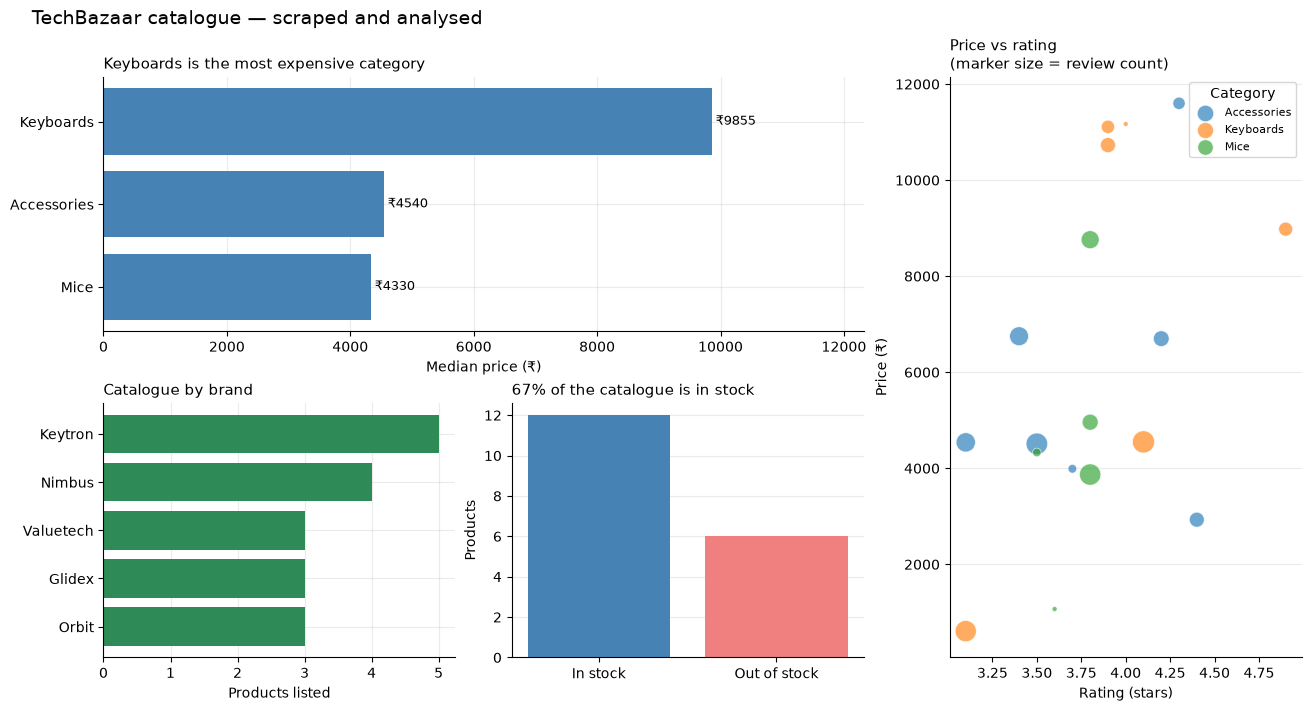

In [96]:
fig, axd = plt.subplot_mosaic(
    [["price_by_cat", "price_by_cat", "rating_price"],
     ["brands", "stock", "rating_price"]],
    figsize=(13, 7), layout="constrained",
)

# Median price by category
ax = axd["price_by_cat"]
cats = by_category.sort_values("median_price")
bars = ax.barh(cats.index, cats["median_price"], color="steelblue")
ax.bar_label(bars, fmt="₹%.0f", padding=3, fontsize=9)
ax.set_xlabel("Median price (₹)")
ax.set_title(f"{cats.index[-1]} is the most expensive category", loc="left", fontsize=11)
ax.set_xlim(0, cats["median_price"].max() * 1.25)

# Price against rating, sized by review count
ax = axd["rating_price"]
scatter_sizes = np.clip(df["reviews"] / 8, 12, 320)
for category, group in df.groupby("category"):
    ax.scatter(group["stars"], group["price"],
               s=np.clip(group["reviews"] / 8, 12, 320),
               alpha=0.65, edgecolor="white", linewidth=0.6, label=category)
ax.set_xlabel("Rating (stars)")
ax.set_ylabel("Price (₹)")
ax.set_title("Price vs rating\n(marker size = review count)", loc="left", fontsize=11)
ax.legend(fontsize=8, title="Category")

# Products per brand
ax = axd["brands"]
brand_counts = df["brand"].value_counts().sort_values()
ax.barh(brand_counts.index, brand_counts.to_numpy(), color="seagreen")
ax.set_xlabel("Products listed")
ax.set_title("Catalogue by brand", loc="left", fontsize=11)
ax.set_xticks(range(0, brand_counts.max() + 1))

# Stock availability
ax = axd["stock"]
stock_counts = df["in_stock"].value_counts()
ax.bar(["In stock", "Out of stock"],
       [stock_counts.get(True, 0), stock_counts.get(False, 0)],
       color=["steelblue", "lightcoral"])
ax.set_ylabel("Products")
ax.set_title(f"{df['in_stock'].mean():.0%} of the catalogue is in stock", loc="left", fontsize=11)

for ax in axd.values():
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for key in ("price_by_cat", "brands"):
    axd[key].grid(axis="x", alpha=0.25)

fig.suptitle("TechBazaar catalogue — scraped and analysed", fontsize=14, x=0.02, ha="left")
plt.show()

Every panel came from data that did not exist in Python ten cells ago. It was fetched over HTTP,
parsed out of HTML, structured into a DataFrame, summarised, and drawn.

The scatter panel uses `np.clip(df["reviews"] / 8, 12, 320)` for the marker sizes: divide the review
count to get it into a sensible range, then clip so that no marker is invisibly small or absurdly
large. Raw counts spanning 8 to 2,400 would give you dots and blobs.

Note the first panel's title: `f"{cats.index[-1]} is the most expensive category"`. It is computed
from the sorted data rather than typed in, so it cannot contradict the chart underneath it. An
earlier draft of this notebook had that title hard-coded, and a change to the price generator
quietly made it false — which is the exact failure the Matplotlib notebook warned about, caught in
its natural habitat.

### Step 6 — save the result

In [97]:
df.to_csv("techbazaar_catalogue.csv", index=False, encoding="utf-8")

reloaded = pd.read_csv("techbazaar_catalogue.csv")
print("saved and reloaded:", reloaded.shape)
print("columns:", reloaded.columns.tolist())

saved and reloaded: (18, 12)
columns: ['sku', 'title', 'brand', 'category', 'price', 'stars', 'reviews', 'in_stock', 'url', 'warranty', 'connection', 'weight_g']


Save the scraped data as soon as you have it, before any analysis. Scraping is the slow, fragile,
impolite part of the pipeline; once the data is in a CSV, every subsequent experiment costs nothing
and touches nobody's server. Re-scraping because you did not save is the most avoidable waste in
this whole workflow.

### What the project demonstrated

- **requests** fetched pages, with timeouts and status checks, over a session, politely spaced.
- **Beautiful Soup** turned each page into a tree and CSS selectors pulled the fields out, with
  helpers that returned `None` instead of crashing on missing data.
- **Pandas** took the list of dictionaries directly, and the audit step caught nothing this time
  precisely because the parsers were written defensively.
- **NumPy** did the correlation and the weighted average.
- **Matplotlib** turned the summary tables into a dashboard, with chart types chosen per question.

And the part that was not about any library: checking the data before trusting it, declining to
report a correlation from eighteen observations, and saving the scrape so it only had to happen
once.

## Solutions

### Finding elements

In [98]:
catalogue_soup = BeautifulSoup(catalogue_html, "html.parser")

# Level 1
print("page title  :", catalogue_soup.title.get_text(strip=True))
print("main heading:", catalogue_soup.select_one("h1").get_text(strip=True))
print("brands      :", [b.get_text(strip=True) for b in catalogue_soup.select("p.brand")])

page title  : TechBazaar — Peripherals
main heading: TechBazaar
brands      : ['Keytron', 'Glidex', 'Keytron']


In [99]:
# Level 2 — with a CSS selector
for article in catalogue_soup.select("article.out-of-stock"):
    print(article["data-sku"], "-", article.select_one("h3.title a").get_text(strip=True))

print()

# the same with find_all
for article in catalogue_soup.find_all("article", class_="out-of-stock"):
    print(article["data-sku"], "-", article.find("h3", class_="title").find("a").get_text(strip=True))

KB-3072 - Ergonomic Split Keyboard

KB-3072 - Ergonomic Split Keyboard


Both work. The `select` version is shorter and the selector reads as one description of what you
want; the `find_all` version needs a chain of three calls to reach the link text.

The selector is also more robust: `h3.title a` finds the link however deeply it is nested, while
`.find("h3").find("a")` breaks if a `<span>` appears between them. For "reach into a structure",
prefer `select`.

In [100]:
# Level 3
def product_count_by_brand(soup):
    """Count products per brand, tolerating products with no brand element."""
    counts = {}
    for article in soup.select("article.product"):
        brand_tag = article.select_one("p.brand")
        brand = clean_text(brand_tag.get_text()) if brand_tag else "Unknown"
        counts[brand] = counts.get(brand, 0) + 1
    return counts


print(product_count_by_brand(catalogue_soup))

# and with a product that has no brand
no_brand_soup = BeautifulSoup(
    catalogue_html.replace('<p class="brand">Glidex</p>', ""), "html.parser")
print(product_count_by_brand(no_brand_soup))

{'Keytron': 2, 'Glidex': 1}
{'Keytron': 2, 'Unknown': 1}


`counts.get(brand, 0) + 1` is the standard dictionary-counting idiom: look the key up with a
default of 0, add one, store it back. `collections.Counter` does the same job with less code:

In [101]:
from collections import Counter

def product_count_by_brand_counter(soup):
    brands = [
        clean_text(a.select_one("p.brand").get_text()) if a.select_one("p.brand") else "Unknown"
        for a in soup.select("article.product")
    ]
    return dict(Counter(brands))


print(product_count_by_brand_counter(catalogue_soup))

{'Keytron': 2, 'Glidex': 1}


The `Counter` version is shorter, and the comprehension calls `select_one` twice for every product
to avoid a crash — which is the kind of thing that makes a one-liner worse than the loop. The
explicit version above is the one to keep.

### Extracting and navigating

In [102]:
# Level 1
for article in catalogue_soup.select("article.product"):
    title = article.select_one("h3.title a").get_text(strip=True)
    brand = article.select_one("p.brand").get_text(strip=True)
    price = int(article.select_one("p.price")["data-paise"]) / 100
    print(f"{title:32} {brand:10} ₹{price:>10,.2f}")

Mechanical Keyboard TKL          Keytron    ₹  4,299.00
Wireless Mouse Pro               Glidex     ₹  1,599.00
Ergonomic Split Keyboard         Keytron    ₹  8,999.00


In [103]:
# Level 2
def product_urls(soup, base):
    """Absolute URLs for every product on the page."""
    return [urljoin(base, a["href"]) for a in soup.select("article.product h3.title a")]


urls = product_urls(catalogue_soup, "https://techbazaar.example.com/")
for url in urls:
    product_id = urlparse(url).path.rstrip("/").split("/")[-1]
    print(f"{product_id:6} {url}")

1024   https://techbazaar.example.com/products/1024
2048   https://techbazaar.example.com/products/2048
3072   https://techbazaar.example.com/products/3072


`urlparse(url).path.rstrip("/").split("/")[-1]` takes the last segment of the path. The `rstrip("/")`
guards against a trailing slash, which would otherwise make the last segment an empty string — a
small thing that bites when a site is inconsistent about trailing slashes.

In [104]:
# Level 3
def get_spec(table, label, default=None):
    """Look up a spec value by label, ignoring case and surrounding whitespace."""
    wanted = label.strip().casefold()
    for row in table.find_all("tr"):
        key = row.find("th")
        value = row.find("td")
        if key and value and key.get_text(strip=True).casefold() == wanted:
            return value.get_text(strip=True)
    return default


specs_table = spec_soup.find("table", class_="specs")

print("weight    :", get_spec(specs_table, "weight"))
print("warranty  :", get_spec(specs_table, "  Warranty "))
print("colour    :", get_spec(specs_table, "Colour"))
print("colour, with a default:", get_spec(specs_table, "Colour", default="not listed"))

weight    : 780 g
warranty  : 2 years
colour    : None
colour, with a default: not listed


`casefold()` rather than `lower()` is the correct choice for case-insensitive comparison. For
English they behave the same; `casefold` also handles cases like the German "ß", which `lower`
leaves alone but `casefold` turns into "ss" so that it compares equal to "SS".

The `if key and value and ...` guard skips rows that do not have both cells, so a header or
footnote row cannot cause a crash.

### Requests, scraping and pagination

In [105]:
# Level 1
response = requests.get(f"{BASE_URL}/page/2.html", timeout=10)

if response.status_code == 200:
    page_soup = BeautifulSoup(response.content, "html.parser")
    for article in page_soup.select("article.product"):
        print(article["data-sku"], "-", article.select_one("h3.title a").get_text(strip=True))
else:
    print(f"could not fetch the page: HTTP {response.status_code}")

print()

missing = requests.get(f"{BASE_URL}/page/404.html", timeout=10)
if missing.status_code == 200:
    print("parsing…")
else:
    print(f"could not fetch the page: HTTP {missing.status_code}")

MI-1021 - Gaming Mouse 16K DPI
KE-1028 - Low-Profile Bluetooth Keyboard
MI-1035 - Vertical Ergonomic Mouse

could not fetch the page: HTTP 404


The same code path handles both, because the status check comes before the parsing. Parsing first
and checking afterwards is the mistake — by then you have a soup of an error page and your
selectors return nothing for no visible reason.

In [106]:
# Level 2
def scrape_page(url):
    """Product dictionaries for one listing page. Empty list if the page cannot be fetched."""
    response = fetch(url)
    if response is None:
        return []
    page_soup = BeautifulSoup(response.content, "html.parser")
    return [parse_product(article, url) for article in page_soup.select("article.product")]


all_records = []
for page_number in range(1, n_pages + 1):
    all_records.extend(scrape_page(f"{BASE_URL}/page/{page_number}.html"))
    time.sleep(0.02)

skus = [record["sku"] for record in all_records]

print("products collected:", len(all_records))
print("unique SKUs       :", len(set(skus)))
print("no duplicates     :", len(skus) == len(set(skus)))

products collected: 18
unique SKUs       : 18
no duplicates     : True


Returning an empty list on failure — rather than `None` — is what lets `extend` be called
unconditionally. A function that sometimes returns a list and sometimes `None` forces every caller
to check, and one of them eventually forgets.

`len(skus) == len(set(skus))` is the standard duplicate check: a set discards repeats, so if the
lengths match, there were none.

In [107]:
# Level 3
def scrape_detail(url):
    """Name, price and flattened spec table for one product page."""
    blank = {"name": None, "price": None, "url": url}

    response = fetch(url)
    if response is None:
        return blank

    detail_soup = BeautifulSoup(response.content, "html.parser")
    name_tag = detail_soup.select_one("h1.product-name")
    price_tag = detail_soup.select_one("p.price")
    table = detail_soup.find("table", class_="specs")

    specs = parse_spec_table(table) if table else {}
    flattened = {key.strip().lower().replace(" ", "_"): value for key, value in specs.items()}

    return {
        "name": clean_text(name_tag.get_text()) if name_tag else None,
        "price": int(price_tag["data-paise"]) / 100 if price_tag and price_tag.get("data-paise") else None,
        "url": url,
        **flattened,
    }


sample_urls = [record["url"] for record in all_records[:3]]
sample_urls.append(f"{BASE_URL}/product/does-not-exist.html")

details = pd.DataFrame([scrape_detail(url) for url in sample_urls])
print(details[["name", "price", "brand", "weight", "warranty"]].to_string())

  got HTTP 404 for http://127.0.0.1:8731/product/does-not-exist.html
                       name    price    brand weight warranty
0   Mechanical Keyboard TKL  11110.0  Keytron  824 g   1 year
1        Wireless Mouse Pro   8760.0   Glidex  242 g   1 year
2  Ergonomic Split Keyboard  11170.0  Keytron  743 g  3 years
3                       NaN      NaN      NaN    NaN      NaN


The missing page produced a row with `None` in every column instead of stopping the loop — which is
what the `blank` dictionary at the top of the function is for. Returning a consistent shape on
failure matters more than it looks: every row of the DataFrame then has the same columns, and the
failures are visible as missing values you can count.

The dictionary comprehension `{key.strip().lower().replace(" ", "_"): value for ...}` normalises the
spec labels into usable column names in one step. Without it you would get columns called `SKU` and
`Connection` alongside `name` and `price`, and a mix of naming conventions in one table is the kind
of small friction that causes typos for the rest of the analysis.

Note that `parse_spec_table` is reused unchanged from the navigation section, and
`parse_product` from the scraper section. Writing the parsers as functions over an element — rather
than as code inside a loop over pages — is what made that reuse free.

## Quick reference

**Fetch**

```python
import requests
r = requests.get(url, timeout=10, headers={"User-Agent": "MyBot/1.0 (contact@example.com)"})
r.status_code   r.ok   r.text   r.content   r.json()   r.headers   r.url
r.raise_for_status()                      # raise on 4xx/5xx
r.encoding = "utf-8"                      # fix a wrong declared encoding

with requests.Session() as s:             # reuse the connection
    s.headers.update({...})
    s.get(url, timeout=10)
```

**Parse**

```python
from bs4 import BeautifulSoup
soup = BeautifulSoup(r.content, "html.parser")     # or "lxml"
soup.prettify()
```

**Find**

```python
soup.find("div")                          soup.find_all("div", limit=5)
soup.find("p", class_="price")            soup.find_all(["h1", "h2"])
soup.find(id="main")                      soup.find_all(attrs={"data-sku": True})
soup.find_all(string=lambda t: t and "x" in t)
soup.find_all(my_filter_function)
```

**CSS selectors**

```python
soup.select_one(".price")                 soup.select("article.product h3.title a")
soup.select(".product.in-stock")          soup.select('a[href^="/product"]')
soup.select(".grid > article")            soup.select("h1, h2")
```

**Extract**

```python
tag.get_text(strip=True)                  tag.get_text(" ", strip=True)
tag["href"]                               tag.get("data-sku", default)
tag.attrs                                 tag["class"]          # a list
urljoin(base_url, tag["href"])            urlparse(url).path
```

**Navigate**

```python
tag.parent          tag.parents            tag.find_parent("article")
tag.children        tag.descendants        tag.find_all(recursive=False)
tag.find_next_sibling("td")               tag.find_previous_sibling()
tag.find_next("p")                        tag.find_previous("h2")
```

**Patterns worth copying**

```python
# Safe field extraction
def text_of(el, selector, default=None):
    found = el.select_one(selector)
    return found.get_text(strip=True) if found else default

# Follow pagination
url, visited = start_url, set()
while url and url not in visited:
    visited.add(url)
    r = requests.get(url, timeout=10)
    if r.status_code != 200:
        break
    soup = BeautifulSoup(r.content, "html.parser")
    records.extend(parse(a, url) for a in soup.select(".record"))
    nxt = soup.select_one("a.next")
    url = urljoin(url, nxt["href"]) if nxt else None
    time.sleep(1)

# Straight into Pandas
df = pd.DataFrame(records)
```

**Be a good citizen**

```python
import urllib.robotparser
rp = urllib.robotparser.RobotFileParser()
rp.set_url("https://example.com/robots.txt"); rp.read()
rp.can_fetch("*", url)        rp.crawl_delay("*")

time.sleep(1)                 # between requests
# cache pages to disk; fetch once, parse many times
```

## Shutting down the demo server

Run this last. It stops the web server, frees the port and removes the files the notebook created.

In [108]:
import shutil

server.shutdown()
server.server_close()
print("server stopped")

for path in [site_dir, cache_dir]:
    shutil.rmtree(path, ignore_errors=True)
Path("techbazaar_catalogue.csv").unlink(missing_ok=True)

print("demo files removed:", not site_dir.exists(), not cache_dir.exists())

server stopped
demo files removed: True True


`server.shutdown()` stops the request loop and `server_close()` releases the port, so re-running
the notebook from the top does not fail with "address already in use".

If you interrupted the notebook earlier and the port is stuck, restart the kernel — the server
thread dies with it.

## The four notebooks together

```text
Beautiful Soup + requests     collect data that exists only as web pages
          ↓
Pandas                        structure it, clean it, group it, join it
          ↓
NumPy                         the numerical work underneath
          ↓
Matplotlib                    make it understandable
```

That is a complete data workflow, and you have now written every stage of it.

What to do next, in rough order of value:

1. **Pick a question you actually care about** and answer it end to end. Cricket statistics, flat
   prices in your city, your own bank statements, a public dataset from data.gov.in. A real
   question teaches you more than any tutorial, because the data will not cooperate.
2. **Learn Seaborn.** It sits on Matplotlib and makes statistical charts — distributions by group,
   pair plots, regression plots — much shorter to write. Everything in the Matplotlib notebook
   still applies underneath it.
3. **Read the documentation of the library you use most.** Pandas' user guide in particular is
   good, and nobody reads it. The "Cookbook" section is full of patterns worth stealing.
4. **Learn to write a few tests.** Once a cleaning or parsing function matters, a handful of
   assertions about known inputs will save you more time than any new library.

And the habit underneath all four notebooks: check the shape, check the dtypes, check the row
count, and look at the data before you trust a result. Every genuinely expensive mistake in this
field is a confident answer to a question the data could not support.